# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Проект содержит исследование и обучение модели для предсказания оттока пользователей сервиса доставки кофе. В проекте используется модель LogisticRegression для бинарной классификации.

# План работы

1. Подготовка среды и библиотек, загрузка датасета
2. Первичный анализ данных
3. Предобработка данных
4. Обучение базовой версии модели
5. Обучение модели с добавлением новых признаков
6. Эксперименты с гиперпараметрами
7. Обучение финальной модели
8. Выводы
9. Сохранение модели в файл для производственной эксплуатации

## Этап 1. Подготовка среды и библиотек и загрузка датасета
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
%%capture
!pip install phik==0.12.5
!pip install joblib==1.5.3

In [2]:
import os
import requests
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from scipy.stats import uniform, loguniform
 # для определения зависимости app_opens_per_week от order_frequency_week
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from phik import phik_matrix

import joblib

In [3]:
RANDOM_STATE = 153
np.random.seed(RANDOM_STATE)

In [4]:
def load_dataset(
    dataset_url,
    local_file,
    local_path='datasets',
    sep=',',
    decimal='.'
):
    local_dataset_file = f'{local_path}/{local_file}'
    remote_dataset_url = dataset_url
    def read_dataset_csv():
        return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

    try:
        df = read_dataset_csv()
        print(f'Датасет успешно загружен из {local_dataset_file}')
    except FileNotFoundError:
        os.makedirs(local_path, exist_ok=True)
        print(f'Файл не найден. Загружаем файл в {local_dataset_file} из {remote_dataset_url}')
        response = requests.get(remote_dataset_url)
        if response.status_code == 200:
            with open(local_dataset_file, 'wb') as f:
                f.write(response.content)
            print(f'Файл с датасетом успешно загружен в {local_dataset_file}')
            df = read_dataset_csv()
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')
    return df

In [5]:
df = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv',
    local_file='coffee_churn_dataset.csv'
)

Датасет успешно загружен из datasets/coffee_churn_dataset.csv


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [7]:
df.head(5)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Датасет успешно загружен. Датасет содержит признаки 10450 объектов в 26 колонках и 1 целевой признак - churn.


## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

В датасете содержится агрегированная информация по пользователям и их поведению в сервисе покупки и доставки кофе. Состав датасета:
```
 0   user_id                   10450 non-null  str      — идентификатор пользователя.
 1   days_since_last_order     9505 non-null   float64  — количество дней, прошедших с последнего заказа.
 2   order_frequency_month     9850 non-null   float64  — среднее число заказов в месяц.
 3   order_frequency_week      10062 non-null  float64  — среднее число заказов в неделю.
 4   avg_order_value           9867 non-null   float64  — средний чек, в рублях.
 5   median_order_value        9619 non-null   float64  — медианный чек, в рублях.
 6   total_spent_last_month    10156 non-null  float64  — сумма заказов (потраченных рублей) за последний месяц.
 7   total_spent_last_week     9506 non-null   float64  — сумма заказов за последнюю неделю.
 8   discount_usage_rate       10053 non-null  float64  — доля заказов со скидкой за последний месяц.
 9   last_coffee_type          10192 non-null  str      — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
 10  preferred_roast           10334 non-null  str      — предпочитаемый тип обжарки.
 11  milk_preference           9782 non-null   str      — предпочитаемый тип молока.
 12  seasonal_menu_tried       9461 non-null   float64  — отметка о том, пробовал ли пользователь новейшее сезонное меню.
 13  coffee_bean_origin        9768 non-null   str      — страна происхождения зерна.
 14  last_drink_size           9946 non-null   str      — размер последнего заказа, совершённого на момент сбора данных.
 15  subscription_status       9512 non-null   str      — тип подписки пользователя.
 16  app_opens_per_week        9554 non-null   float64  — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
 17  notifications_enabled     9913 non-null   float64  — включены ли у пользователя уведомления.
 18  review_rating_last_10     9757 non-null   float64  — средняя оценка последних на момент сбора данных десяти заказов клиента.
 19  review_rating_last_1      9593 non-null   float64  — оценка последнего на момент сбора данных заказа клиента.
 20  app_crashes_last_month    9729 non-null   float64  — сколько раз приложение зависало за последний месяц.
 21  seasons                   9771 non-null   str      — текущее время года.
 22  days_since_last_promo     9719 non-null   float64  — сколько дней прошло с последнего использования акции или промокода.
 23  phone_type                10114 non-null  str      — тип устройства, с которого пользователь чаще всего совершал покупки.
 24  coffee_preference_change  9840 non-null   float64  — менялись ли вкусовые предпочтения пользователя.
 25  geo_location              10340 non-null  str      — идентификатор региона пользователя.
 26  churn                     10450 non-null  int64    — перестал ли пользователь пользоваться сервисом.
 ```

Состав таблицы соответствует описанию. Типы столбцов корректны. В некоторых случаях они могут быть скорректированы в меньшую размерность, но в виду небольшого размера датасета (2.2 МБ) мы этого делать не будем.

Для обучения модели логистической регрессии, предсказывающей отток пользователей из сервиса, можно исключить из датасета незначимые признаки:

- user_id - так как это технический идентификатор, который не может влиять на вероятность оттока
- seasons - текущее время года предположительно не влияет на вероятность оттока

Проверим влияние seasons на вероятность оттока:

In [8]:
df.groupby('seasons').agg({
    'user_id': 'count',
    'churn': 'mean',
})

,user_id,churn
seasons,,
autumn,2433,0.057953
spring,2507,0.063422
summer,2408,0.056894
winter,2423,0.056954


Судя по разнице между разными сезонами в разрезе таргета (в большинстве сезонов положительная группа составляет 5.7% пользователей, весной - 6.3%), сезон как-то влияет на целевую переменную. Оставим ее до корреляционного анализа.

Столбец `user_id` оставим до момента рассмотрения дубликатов в датасете, так как он может давать дополнительную информацию о проблемах датасета в случае расследования таковых.


### Описательная статистика датасета

Приведем описательную статистику датасета:

In [9]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


Из статистики обращают на себя несколько проблем:

- min order_frequency_week (ср. число заказов в неделю) имеет отризательные значения
- min avg_order_value (ср. чек в рублях) имеет отрицательные значения
- min median_order_value (медианный чек) имеет отрицательные значения
- min total_spent_last_month (сумма покупок за последний месяц) имеет отрицательные значения
- min total_spent_last_week (сумма покупок за последнюю неделю) имеет отрицательные значения
- min review_rating_last_1 (рейтинг последнего отзыва) имеет отрицательные значения
- есть выбросы в total_spent_last_month (80к рублей максимальное значение)
- mean churn = 0.06, то есть мы имеем дело с дисбалансом классов - всего 6% пользователей принадлежат положительному классу, то есть в датасете отмечены как ушедшие из сервиса

Оценим распределение целевой переменной по частоте встречаемых значений:

In [10]:
df['churn'].value_counts(dropna=False)

churn
0    9821
1     629
Name: count, dtype: int64

Тут нет сюрпризов, целевая переменная принимает только значения 0 (пользователь не ушел из сервиса) и 1 (пользователь ушел из сервиса)

### Оценка пропусков

Оценим количество и долю пропусков в колонках.

In [11]:
def na_info(df, round_digits=1):
    '''
    Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
    '''
    count_na_name = 'Количество пропусков'
    res = pd.DataFrame({
        'Количество строк': len(df),
        count_na_name: df.isna().sum(),
        'Процент пропусков': round(df.isna().mean()*100, round_digits)
    }).sort_values(by=count_na_name, ascending=False)
    return res.query(f'`{count_na_name}` > 0').reset_index()

na_info(df)

,index,Количество строк,Количество пропусков,Процент пропусков
0,seasonal_menu_tried,10450,989,9.5
1,days_since_last_order,10450,945,9.0
2,total_spent_last_week,10450,944,9.0
3,subscription_status,10450,938,9.0
4,app_opens_per_week,10450,896,8.6
5,review_rating_last_1,10450,857,8.2
6,median_order_value,10450,831,8.0
7,days_since_last_promo,10450,731,7.0
8,app_crashes_last_month,10450,721,6.9
9,review_rating_last_10,10450,693,6.6


Данные в 25 колонках (во всех кроме user_id и churn) содержат пропуски: от 100 до 1000 пропусков (1-10%) в различных колонках.
Важно будет исследовать причины возникновения пропусков в наиболее связанных с целевой переменной столбцах, например, скорее всего days_since_last_order, total_spent_last_week, app_opens_per_week и другие в топе по проценту пропусков необходимо будет заполнить, чтобы не потерять большую часть обучающей выборки. Восстановление пропусков при правильно выбранной стратегии позволит повысить качество конечной модели классификации.


Далее рассмотрим каждый пропуск и выберем стратегию работы с ним.

#### Пропуски seasonal_menu_tried

In [12]:
df['seasonal_menu_tried'].value_counts(dropna=False)

seasonal_menu_tried
1.0    6634
0.0    2827
NaN     989
Name: count, dtype: int64

Большинство пользователей пробовали сезонное меню, но о 9.5% объектов эта информация не известна. Можно предположить, что пропуск в признаке `seasonal_menu_tried` можно интерпретировать как 0 то есть, пользователь не пробовал сезонное меню. Проверим это связью с целевой переменной.

In [13]:
df.groupby('seasonal_menu_tried', dropna=False).agg({
    'user_id': 'count',
    'churn': 'mean',
})

,user_id,churn
seasonal_menu_tried,,
0.0,2827,0.064025
1.0,6634,0.060748
NaN,989,0.045501


Видно, что пользователи, не пробовавшие сезонное меню, имеют долю покинувших сервис 6.3%, тогда как у пробовавших меню - доля составляет 6.1%. Это небольшое изменение и может быть вызвано шумом в данных. Тем более , что этот показатель сосавляет 4.7% у группы с пропущенным значением seasonal_menu_tried.

Исходя из этого, следует заменить пропущенные значения скорее на наиболее часто встречающееся значение, а именно на 1 (пробовали сезонное меню).

#### Пропуски days_since_last_order

Рассмотрим варианты возникновения пропусков в колонке days_since_last_order, для этого посмотрим на данные:

In [14]:
df[df['days_since_last_order'].isna()].head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
12,user_03894,NaN,4.458034,1.033529,501.118205,307.718451,1401.250496,281.276772,0.310868,arabica,...,1.0,NaN,NaN,1.0,summer,1.0,ios,0.0,geo_30,0
58,user_00135,NaN,10.656956,2.448093,1398.672006,507.027724,4865.231680,938.801320,0.140481,robusta,...,1.0,3.546802,3.945666,1.0,summer,2.0,web,0.0,geo_2,1
70,user_09835,NaN,3.774756,0.853346,2226.967063,668.564225,2457.516038,576.286670,0.356142,robusta,...,1.0,3.970716,3.624204,2.0,NaN,12.0,android,0.0,geo_67,0
87,user_08616,NaN,2.142568,0.484878,2267.050390,730.342995,1362.723976,249.478388,0.469791,robusta,...,1.0,4.473398,4.568103,0.0,summer,0.0,ios,0.0,geo_5,0
105,user_00543,NaN,4.568129,1.048570,553.844153,221.219995,1204.884041,163.691112,0.267677,arabica,...,0.0,4.470813,3.291388,0.0,summer,19.0,android,0.0,geo_50,0
115,user_10440,NaN,4.208999,1.020259,473.299755,NaN,749.371189,202.538020,0.085882,blend,...,1.0,4.872669,1.427168,4.0,winter,22.0,ios,0.0,geo_14,1
129,user_09350,NaN,3.803244,0.915704,658.861440,288.503991,1103.409475,204.276115,0.171170,robusta,...,1.0,5.481489,0.936321,0.0,autumn,8.0,web,0.0,geo_2,0
132,user_07914,NaN,9.775555,2.511756,1105.174218,827.810399,7144.012860,2559.595482,NaN,arabica,...,0.0,5.237941,4.812748,1.0,summer,27.0,web,0.0,geo_11,0
143,user_02974,NaN,2.902275,0.544056,1027.070680,454.297932,1525.139916,314.575374,0.455186,arabica,...,1.0,4.527124,4.895114,1.0,winter,3.0,ios,0.0,geo_2,0
171,user_09586,NaN,1.303344,0.353423,1136.943823,641.463108,709.217352,258.100452,0.561902,arabica,...,1.0,4.682276,2.612746,1.0,autumn,4.0,android,0.0,geo_69,0


Пропуски в колонке days_since_last_order в размере около 900 шт (9%) похожи на технический сбой выгрузки данных, так как одновременно с пустыми значениями в этом столбце встречаются непустые значения в столбце days_since_last_promo (сколько дней прошло с последнего использования акции или промокода). Очевидно, что промо и акции не применяются без осуществления заказа.
В пропущенных значениях в days_since_last_order можно использовать значения из days_since_last_promo. Дополнительно посчитаем, сколько таких пропусков невозможно будет исправить таким образом:

In [15]:
df[df['days_since_last_order'].isna() & df['days_since_last_promo'].isna()]['user_id'].count()

np.int64(57)

Всего лишь 57 записей не получится исправить подобным образом. Их можно будет заполнить медианным значением.

#### Пропуски total_spent_last_week


Столбец total_spent_last_week - сумма заказов за последнюю неделю. То есть, это траты клиента на заказы кофе за последнюю неделю, предположительно в рублях.
Пропущенные значения в этом столбце могут быть вызваны:

- отсутствием трат клиента на заказы кофе за последнюю неделю
- технической ошибкой выгрузки или сбора данных

Предположим, что так обозначаются нулевые траты за последнюю неделю. Проверим, есть ли в выборке нулевые значения трат за последнюю неделю. Если их нет, то пропуски вероятно означают нулевые траты.

С другой стороны, можно провалидировать данную проверку с помощью дополнительных столбцов. 
Если рассмотреть пропущенные значения в столбце total_spent_last_week в совокупности со столбцами 'days_since_last_order', 'days_since_last_promo', то видно, что эти колонки в подавляющем числе случаев присутствуют в выборке, где total_spent_last_week пропущено (~800 из ~900 содержат ненулевые значения).
Если значения в days_since_last_order и days_since_last_promo меньше 7 дней, то это может означать, что у данных объектов были заказы, но потраченная сумма за заказ не была внесена или равнялась нулю (если действовали промо акции на 100% покупку, что маловероятно, так как обычно акции покрывают часть трат на заказ).

In [16]:
# проверим, есть ли нулевые траты на заказы в датасете
df[(df['total_spent_last_week'] > 0) & (df['total_spent_last_week'] < 1)]

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
567,user_03898,3.0,0.333525,0.008515,144.101615,NaN,36.661996,0.950258,0.142331,arabica,...,1.0,2.738251,NaN,0.0,spring,4.0,ios,0.0,geo_100,0


Есть только 1 запись с близким к нулю временем total_spent_last_week, то есть в случае отсутствия заказов пользователя в датасете предположительно фигурирует total_spent_last_week=NaN

Провалидируем эту гипотезу с помощью колонок days_since_last_order/promo

In [17]:
print('Количество пользователей с пропусками в total_spent_last_week при этом имеющих заказы за послденюю неделю:')
df[(df['total_spent_last_week'].isna()) & ((df['days_since_last_promo'] < 7)|(df['days_since_last_order'] < 7))].shape[0]

Количество пользователей с пропусками в total_spent_last_week при этом имеющих заказы за послденюю неделю:


766

Около 700 объектов имеют пропуски в total_spent_last_week и при этом эти пользователи делали заказ или применяли промо менее чем 7 дней назад (days_since_last_promo < 7 или days_since_last_order < 7). Налицо несогласованность в данных. Если пользователь делал заказ в течение недели, то total_spent_last_week не может быть равен нулю.

Получается, что гипотеза о том, пропуски в total_spent_last_week являются выражением нулевых трат пользователей, не подтвердилась. Но зато теперь мы можем заполнить пропуски в total_spent_last_week, для пользователей, у которых days_since_last_promo < 7 или days_since_last_order < 7 по формуле:

```python
total_spent_last_week = total_spent_last_month/4 if days_since_last_promo < 7 or days_since_last_order < 7 else 0
```

Логика такая: пропуски для этих пользователей были допущены по ошибке, так как траты за последнюю неделю у пользователя были, но они не отражены в датасете. Пропуски заполним делением месячных трат на 4 (количество недель в месяце), иначе 0, то есть траты нулевые.

Проверим еще одну гипотезу: пропуски не носят тенденциозный характер, то есть не обусловлены зависимостью с таргетом и другими признаками. Если такая связь есть, то при невозможности восстановления, Для проверки сравним средние значения для выборок с пропуском и без пропусков.


Дополнительно провалидируем случайность пропусков в этом столбце, сравнив средние значения числовых признаков для выборки пользователей без пропусков и выборки пользователей с пропусками:

Различие в процентах между средними значениями двух выборок
 с пропусками в total_spent_last_week (944 объектов) и без (9506 объектов):


,Средние без пропусков,Средние с пропусками,Различие абсолютное,Различие в процентах
days_since_last_order,4.424936,4.084983,-0.339954,-7.68
notifications_enabled,0.754575,0.737723,-0.016851,-2.23
median_order_value,453.316842,445.969054,-7.347787,-1.62
seasonal_menu_tried,0.702234,0.690888,-0.011346,-1.62
avg_order_value,1065.253551,1048.468059,-16.785492,-1.58
review_rating_last_1,4.021280,4.034389,0.013110,0.33
order_frequency_week,0.930383,0.933759,0.003375,0.36
review_rating_last_10,4.205047,4.223592,0.018545,0.44
order_frequency_month,4.023872,4.043726,0.019854,0.49
discount_usage_rate,0.283815,0.290811,0.006996,2.46


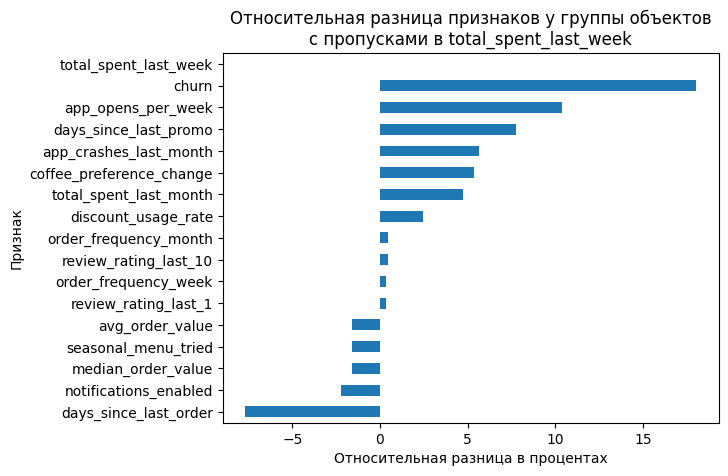

In [18]:
def compare_means(df, column_name, show_std=False):
    df_na = df[df[column_name].isna()]
    df_notna = df[~df[column_name].isna()]
    mean_na = df_na.describe().loc['mean']
    std_na = df_na.describe().loc['std']
    mean_notna = df_notna.describe().loc['mean']
    std_notna = df_notna.describe().loc['std']

    print('Различие в процентах между средними значениями двух выборок\n',
        f'с пропусками в {column_name} ({len(df_na)} объектов) и',
        f'без ({len(df_notna)} объектов):')
    diff = mean_na - mean_notna
    diff_pct = round(diff/mean_notna * 100, 2)
    compare_result = pd.DataFrame({
        'Средние без пропусков': mean_notna,
        'Средние с пропусками': mean_na,
        'Различие абсолютное': diff,
        'Различие в процентах': diff_pct
    }).sort_values(by='Различие в процентах')
    if show_std:
        compare_result['σ без пропусков'] = std_notna
        compare_result['σ с пропусками'] = std_na

    display(compare_result)

    compare_result.plot(
        kind='barh',
        y='Различие в процентах',
        title=f'Относительная разница признаков у группы объектов\nс пропусками в {column_name}',
        xlabel='Относительная разница в процентах',
        ylabel='Признак',
        legend=False,
    )
    plt.show()

compare_means(df, 'total_spent_last_week')

Из таблицы и графика видно, что почти все признаки отличаются у двух рассмотренных групп незначительно (в пределах 10%).
Есть отличие в колонке churn - у группы с пропусками доля ушедших пользователей выше на 1 пп (7 вместо 6), но это можно отнести к шуму, так как выборка с пропусками в 10 раз меньше и составляет около 1000 объектов.

#### Пропуски в subscription_status

Попробуем определить природу пропусков в subscription_status

In [19]:
df.groupby(['subscription_status'], dropna=False).agg({
    'user_id': 'count',
    'churn': 'mean',
})

,user_id,churn
subscription_status,,
basic,2862,0.053809
none,3803,0.050224
premium,1923,0.070203
pro,924,0.108225
NaN,938,0.052239


Всего в датасете встречается около 1000 пропусков в статусе подписки.
Из таблицы видно, что судя по связи с целевой переменной, скорее всего эти пропуски можно заменить на статус `none`: доля ушедших пользователей равна 5% и кроме того это наиболее частая категория.

Дополнительно проведем анализ отличий выборки пользователей с пропусками от пользователей без пропусков. 

Различие в процентах между средними значениями двух выборок
 с пропусками в subscription_status (938 объектов) и без (9512 объектов):


,Средние без пропусков,Средние с пропусками,Различие абсолютное,Различие в процентах
churn,0.060976,0.052239,-0.008737,-14.33
coffee_preference_change,0.193790,0.179256,-0.014534,-7.50
app_crashes_last_month,1.016460,0.981374,-0.035086,-3.45
median_order_value,453.278402,446.233813,-7.044589,-1.55
review_rating_last_1,4.027800,3.967534,-0.060266,-1.50
discount_usage_rate,0.284814,0.280724,-0.004090,-1.44
review_rating_last_10,4.211021,4.162932,-0.048089,-1.14
seasonal_menu_tried,0.701889,0.693976,-0.007913,-1.13
avg_order_value,1064.748126,1053.445203,-11.302923,-1.06
notifications_enabled,0.752933,0.754266,0.001333,0.18


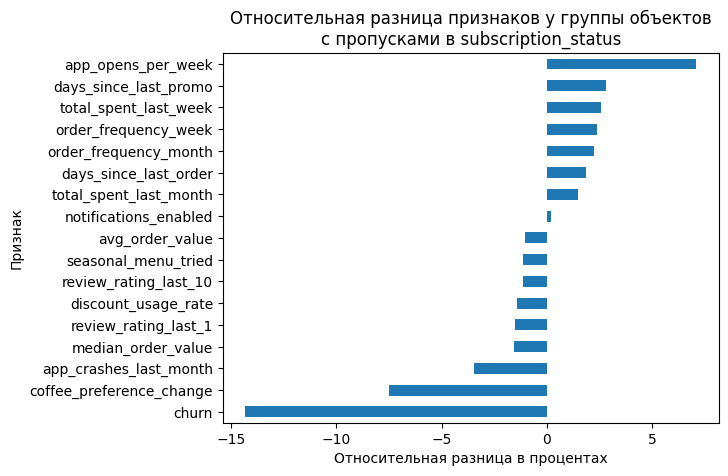

In [20]:
compare_means(df, 'subscription_status')

Из таблицы видно, что различие в процентах не превышает как правило 10%, исключением является шумящий таргет. Не будем на него обращать внимание, так как выше мы выяснили, что пропуски в этой колонке похожи на статус подписки `none`

#### Пропуски в app_opens_per_week


Различие в процентах между средними значениями двух выборок
 с пропусками в app_opens_per_week (896 объектов) и без (9554 объектов):


,Средние без пропусков,Средние с пропусками,Различие абсолютное,Различие в процентах
churn,0.061022,0.051339,-0.009682,-15.87
coffee_preference_change,0.193441,0.182249,-0.011192,-5.79
app_crashes_last_month,1.018466,0.959906,-0.058561,-5.75
seasonal_menu_tried,0.702347,0.688889,-0.013458,-1.92
notifications_enabled,0.753367,0.749708,-0.003660,-0.49
order_frequency_week,0.930880,0.928619,-0.002261,-0.24
review_rating_last_1,4.023060,4.016050,-0.007010,-0.17
avg_order_value,1063.866480,1062.410564,-1.455917,-0.14
median_order_value,452.687102,452.278933,-0.408169,-0.09
order_frequency_month,4.023558,4.048335,0.024777,0.62


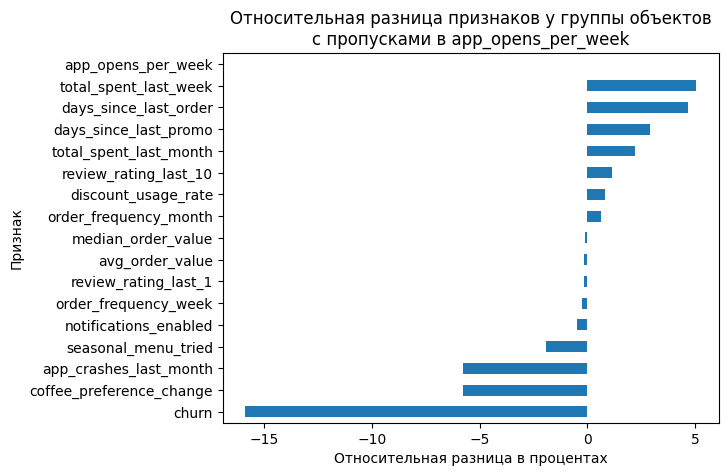

In [21]:
compare_means(df, 'app_opens_per_week')

Для группы с пропусками в колонке app_opens_per_week менее характерен отток (доля 5% вместо 6% - относительная разница 16%). Остальные признаки отличаются менее чем на 6%.

Проверим, как связаны колонки app_opens_per_week с order_frequency_week (среднее количество заказов в неделлю), так как они по сути должны быть связаны: вероятнее всего должна быть линейная зависимость между ними:

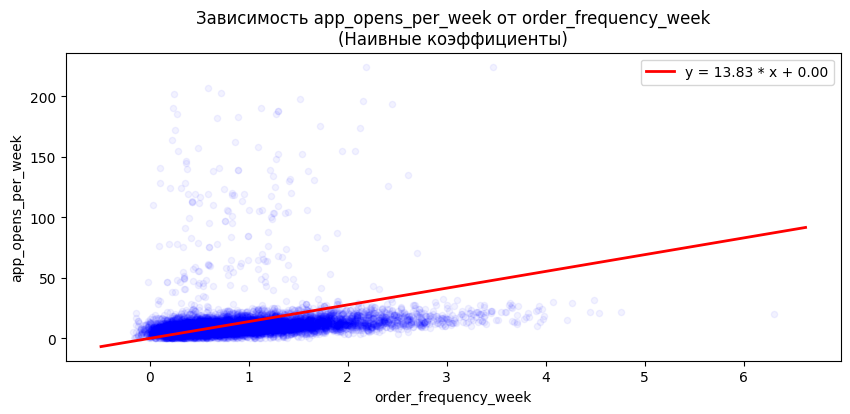

In [22]:
# Удалим пропущенные значения и создадим копию датасета для под данную задачу
df_copy = df[['order_frequency_week', 'app_opens_per_week']].copy()
df_copy.dropna(inplace=True)

# Вычисляем коэффициент среднего отношения (как наивное приближение к линейной модели)
k = (df_copy['app_opens_per_week'] / df_copy['order_frequency_week']).mean()
b = 0

def scatter_with_trend(df, x_col, y_col, k, b, subtitle=None):
    ax = df.plot(
        kind='scatter',
        y=y_col,
        x=x_col,
        alpha=0.05,
        color='blue',
        figsize=(10, 4),
        title=f'Зависимость {y_col} от {x_col}{"" if subtitle is None else "\n" + subtitle}'
    )

    # Строим линию с указанными параметрами
    x_min, x_max = ax.get_xlim()
    x_vals = np.linspace(x_min, x_max, 100)
    y_vals = k * x_vals + b
    plt.plot(x_vals, y_vals, color='red', linewidth=2, label=f'y = {k:.2f} * x + {b:.2f}')

    plt.legend()
    plt.show()

scatter_with_trend(df_copy, 'order_frequency_week', 'app_opens_per_week', k, b, "(Наивные коэффициенты)")

Действительно, как видно на графике, линейная зависимость наблюдается, но подобранный коэффициент не вполне отражает реальную зависимость из-за выбросов. Попробуем подобрать коэффициенты с помощью простейшей линейной модели.

Коффициенты: 3.93, свободный член: 7.76


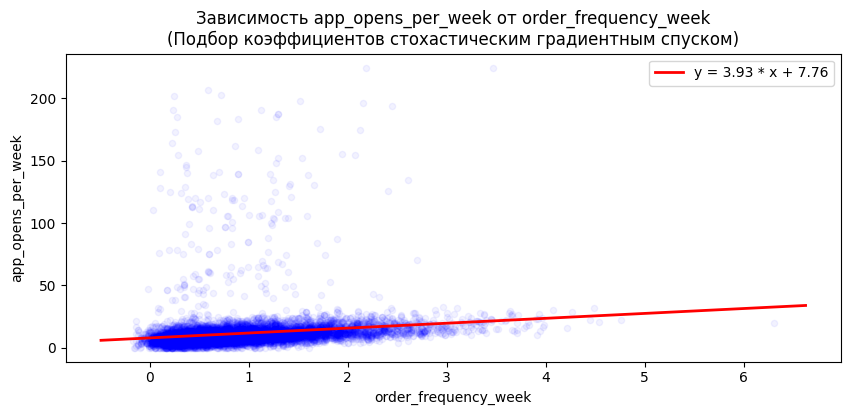

In [23]:
# Ищем линейную зависимость между градиентным спуском:
model = SGDRegressor(random_state=RANDOM_STATE)

model.fit(df_copy[['order_frequency_week']], df_copy['app_opens_per_week'])
k_app_opens_by_order_freq = model.coef_[0]
b_app_opens_by_order_freq = model.intercept_[0]

print(f'Коффициенты: {k_app_opens_by_order_freq:.2f},',
    f'свободный член: {b_app_opens_by_order_freq:.2f}')

scatter_with_trend(
    df_copy,
    'order_frequency_week',
    'app_opens_per_week',
    k=k_app_opens_by_order_freq,
    b=b_app_opens_by_order_freq,
    subtitle='(Подбор коэффициентов стохастическим градиентным спуском)'
)

In [24]:
# посчитаем долю пропусков, которые мы можем исправить с помощью линейного приближения

na_app_opens_count = len(df[df['app_opens_per_week'].isna()])
can_fill_app_opens_count = len(df[df['app_opens_per_week'].isna() & df['order_frequency_week'].notna()])
diff = na_app_opens_count - can_fill_app_opens_count
print(
    f'Доля пропусков app_opens_per_week, которые мы можем исправить с помощью линейного приближения:',
    f'{(can_fill_app_opens_count / na_app_opens_count):.2%} ({diff} строки не сможем)')

Доля пропусков app_opens_per_week, которые мы можем исправить с помощью линейного приближения: 96.32% (33 строки не сможем)


С помощью обучения модели линейной регрессии посредством стахостического градиентного спуска определили коэффициенты зависимости app_opens_per_week от order_frequency_week и теперь можем заполнить с помощью линейной формулы пропуски в данной колонке.

Оставшиеся несколько десятков строк заполним медианой, чтобы не сломать инференс модели в случае отсутствия order_frequency_week.

Мы разобрали топ5 столбцов с наибольшим числом пропусков.

Остальные пропуски заменим медианным (для числовых признаков) либо самым частым (для категориальных признаков) значением в столбцах:
 - review_rating_last_1
 - median_order_value
 - days_since_last_promo
 - app_crashes_last_month
 - review_rating_last_10
 - coffee_bean_origin
 - seasons
 - milk_preference
 - coffee_preference_change
 - order_frequency_month
 - avg_order_value
 - notifications_enabled
 - last_drink_size
 - discount_usage_rate
 - order_frequency_week
 - phone_type
 - total_spent_last_month
 - last_coffee_type
 - preferred_roast
 - geo_location

 В случае неудовлетворительного качества модели, будем продолжать дальнейшую очистку датасета.

### Оценка дубликатов

Оценим явные и неявные дубликаты.

In [25]:
len_before = df.shape[0]
df.drop_duplicates(keep='first', inplace=True)
removed_dup_count = len_before - df.shape[0]
print(
    f'Количество удаленных ЯВНЫХ дубликатов {removed_dup_count}',
    f'({round(removed_dup_count/df.shape[0]*100, 2)}%)'
)

Количество удаленных ЯВНЫХ дубликатов 0 (0.0%)


Явные дубликаты отсутствуют. Оценим неявные дубликаты по различным наборам колонок:

In [26]:
all_colls_without_user_id = [c for c in df.columns if c != 'user_id']
find_dups_subsets = [
    ['user_id'],
    all_colls_without_user_id,
]

true_dup_subsets = []
for subset in find_dups_subsets:
    dup_count = df[df.duplicated(subset=subset, keep=False)].shape[0]
    print(f'Количество дубликатов {dup_count} по подмножеству {subset}')
    if dup_count > 0:
        true_dup_subsets.append(subset)

Количество дубликатов 0 по подмножеству ['user_id']
Количество дубликатов 814 по подмножеству ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']


По user_id дубликатов нет, но есть 814 неявных дубликатов по всем остальным колонкам по исключении user_id.
Посмотрим ближе на эти дубликаты:

In [27]:
# для того, чтобы пандас выводил все колонки и не пропускал их из-за большого числа:
pd.set_option('display.max_columns', None)

df_duplicates = df[df.duplicated(subset=all_colls_without_user_id, keep=False)] \
    .sort_values(by=all_colls_without_user_id)
df_duplicates.head(30)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,coffee_bean_origin,last_drink_size,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
7621,user_09259,0.0,0.175925,0.094914,2300.051408,NaN,110.892458,85.314150,0.428072,robusta,light,soy,1.0,colombia,large,basic,4.820929,1.0,4.224331,5.001820,1.0,NaN,20.0,ios,0.0,geo_16,0
9410,user_10428,0.0,0.175925,0.094914,2300.051408,NaN,110.892458,85.314150,0.428072,robusta,light,soy,1.0,colombia,large,basic,4.820929,1.0,4.224331,5.001820,1.0,NaN,20.0,ios,0.0,geo_16,0
6088,user_10003,0.0,0.190181,0.106029,578.941105,270.139216,58.399093,20.612669,0.288108,arabica,medium,almond,1.0,ethiopia,small,basic,12.527207,0.0,4.124693,4.913105,2.0,spring,7.0,android,0.0,geo_2,0
9558,user_06038,0.0,0.190181,0.106029,578.941105,270.139216,58.399093,20.612669,0.288108,arabica,medium,almond,1.0,ethiopia,small,basic,12.527207,0.0,4.124693,4.913105,2.0,spring,7.0,android,0.0,geo_2,0
4765,user_10215,0.0,0.414051,-0.019292,1895.980125,590.339061,273.584233,NaN,0.256996,blend,medium,NaN,1.0,kenya,large,none,7.303208,0.0,NaN,3.177109,2.0,winter,1.0,android,1.0,geo_70,0
6013,user_01788,0.0,0.414051,-0.019292,1895.980125,590.339061,273.584233,NaN,0.256996,blend,medium,NaN,1.0,kenya,large,none,7.303208,0.0,NaN,3.177109,2.0,winter,1.0,android,1.0,geo_70,0
1336,user_10049,0.0,0.564749,0.115907,940.355012,303.536839,149.764098,26.351746,0.382625,arabica,light,oat,1.0,guatemala,medium,basic,5.488401,1.0,5.014556,2.435400,2.0,winter,NaN,ios,0.0,geo_36,0
8402,user_02279,0.0,0.564749,0.115907,940.355012,303.536839,149.764098,26.351746,0.382625,arabica,light,oat,1.0,guatemala,medium,basic,5.488401,1.0,5.014556,2.435400,2.0,winter,NaN,ios,0.0,geo_36,0
5460,user_04512,0.0,0.808865,0.272680,1047.712286,549.699430,367.513366,138.890770,0.449135,arabica,dark,skim,0.0,colombia,small,premium,16.398552,1.0,4.313193,4.176010,1.0,summer,NaN,ios,1.0,geo_81,0
7924,user_10196,0.0,0.808865,0.272680,1047.712286,549.699430,367.513366,138.890770,0.449135,arabica,dark,skim,0.0,colombia,small,premium,16.398552,1.0,4.313193,4.176010,1.0,summer,NaN,ios,1.0,geo_81,0


На первый взгляд эти пользователи просто задублировались с разными user_id в датасете. Но, возможно это некоторый кластер пользователей, имеющих дубликаты. Проверим это, сравнив распределения признаков объектов без дубликатов и объектов с дубликатами.

In [28]:
means_dup = df_duplicates.describe().loc['mean']
means_dup

days_since_last_order          4.493151
order_frequency_month          4.034751
order_frequency_week           0.946545
avg_order_value             1071.118946
median_order_value           452.335527
total_spent_last_month      1964.695477
total_spent_last_week        417.428703
discount_usage_rate            0.295397
seasonal_menu_tried            0.731707
app_opens_per_week            11.392757
notifications_enabled          0.740885
review_rating_last_10          4.194247
review_rating_last_1           4.012687
app_crashes_last_month         0.965834
days_since_last_promo         14.406417
coffee_preference_change       0.173913
churn                          0.065111
Name: mean, dtype: float64

In [29]:
means_ok = df.drop_duplicates(subset=all_colls_without_user_id, keep='first').describe().loc['mean']
means_ok

days_since_last_order          4.391285
order_frequency_month          4.025081
order_frequency_week           0.929998
avg_order_value             1063.254822
median_order_value           452.643042
total_spent_last_month      1945.439275
total_spent_last_week        412.764040
discount_usage_rate            0.283965
seasonal_menu_tried            0.699868
app_opens_per_week            11.327660
notifications_enabled          0.753518
review_rating_last_10          4.207272
review_rating_last_1           4.022551
app_crashes_last_month         1.015521
days_since_last_promo         14.562969
coffee_preference_change       0.193146
churn                          0.059984
Name: mean, dtype: float64

In [30]:
print(
    'Разница между средними в числовых колонках у двух выборок (дубликвтов/недубликатов) в %:',
    round(np.abs(means_dup - means_ok)/means_ok*100, 1),
    sep='\n',
)

Разница между средними в числовых колонках у двух выборок (дубликвтов/недубликатов) в %:
days_since_last_order        2.3
order_frequency_month        0.2
order_frequency_week         1.8
avg_order_value              0.7
median_order_value           0.1
total_spent_last_month       1.0
total_spent_last_week        1.1
discount_usage_rate          4.0
seasonal_menu_tried          4.5
app_opens_per_week           0.6
notifications_enabled        1.7
review_rating_last_10        0.3
review_rating_last_1         0.2
app_crashes_last_month       4.9
days_since_last_promo        1.1
coffee_preference_change    10.0
churn                        8.5
Name: mean, dtype: float64


Видно, что кластер пользователей с задублировавшимися данными в датасете в целом почти не отличается от остальных пользователей в датасете без дубликатов. Средние значения числовых признаков этих групп пользователей отличаются не более чем на 10%.

Отсюда можно сделать вывод, что задубировавшиеся данные по всем колонкам за исключением user_id - являются неявными дубликатами, возникли предположительно из-за технических ошибок при работе приложения или выгрузке данных и должны быть удалены из датасета, чтобы не оказывать влияние на обучение модели.

In [31]:
len_before = df.shape[0]
df.drop_duplicates(subset=all_colls_without_user_id, keep='first', inplace=True)
removed_dup_count = len_before - df.shape[0]
print(
    f'Количество удаленных неявных дубликатов {removed_dup_count} по всем колонкам без user_id',
    f'что составляет {round(removed_dup_count/df.shape[0]*100, 2)}%'
)

Количество удаленных неявных дубликатов 414 по всем колонкам без user_id что составляет 4.13%


Проверим, есть ли неявные дубликаты среди категориальных признаков:

In [32]:
cat_features = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
    'geo_location',
]

In [33]:

for cat_ftr in cat_features:
    vals = df[cat_ftr].dropna().unique().tolist()
    print(f'[{len(vals)}] {cat_ftr}:', vals)

[3] last_coffee_type: ['blend', 'arabica', 'robusta']
[3] preferred_roast: ['light', 'medium', 'dark']
[6] milk_preference: ['almond', 'whole', 'oat', 'skim', 'soy', 'none']
[6] coffee_bean_origin: ['vietnam', 'guatemala', 'brazil', 'colombia', 'kenya', 'ethiopia']
[3] last_drink_size: ['large', 'medium', 'small']
[4] subscription_status: ['pro', 'none', 'premium', 'basic']
[4] seasons: ['summer', 'autumn', 'spring', 'winter']
[3] phone_type: ['android', 'ios', 'web']
[100] geo_location: ['geo_75', 'geo_95', 'geo_25', 'geo_2', 'geo_19', 'geo_68', 'geo_3', 'geo_45', 'geo_15', 'geo_30', 'geo_93', 'geo_64', 'geo_40', 'geo_87', 'geo_17', 'geo_11', 'geo_94', 'geo_1', 'geo_50', 'geo_67', 'geo_51', 'geo_97', 'geo_16', 'geo_78', 'geo_100', 'geo_98', 'geo_43', 'geo_8', 'geo_48', 'geo_61', 'geo_74', 'geo_35', 'geo_59', 'geo_46', 'geo_5', 'geo_23', 'geo_91', 'geo_42', 'geo_90', 'geo_4', 'geo_96', 'geo_57', 'geo_71', 'geo_54', 'geo_65', 'geo_32', 'geo_14', 'geo_72', 'geo_29', 'geo_9', 'geo_83', 'g

Категориальные признаки не содержат дубликатов. Проверим кат признак geo_location отдельно, так как в нем много значений и ручная проверка нецелесообразна:

In [34]:
list_geo = [geo.split('geo_')[1] for geo in df['geo_location'].dropna().unique().astype(str).tolist()]
list_geo.sort()

set_geo = set(list_geo)
if len(list_geo) != len(set_geo):
    print('В столбце geo_location есть дубликаты!!!')
else:
    print('Дубликатов в geo_location нет')

Дубликатов в geo_location нет


geo_location также не содержит дубликатов

### Анализ категориальных признаков

Категориальные признаки:
- last_coffee_type
- preferred_roast
- milk_preference
- coffee_bean_origin
- last_drink_size
- subscription_status
- seasons
- phone_type
- geo_location

Все категориальные признаки имеют до 6 уникальных значений (кроме geo_location, который имеет 100 значений)
Их можно разделить на 2 группы по стратегии их кодирования:
- OneHotEncoder (все кроме geo_location)
- TargetEncoder (geo_location)



Можно использовать такие комбинации признаков, чтобы получить более точную модель:
-  subscription_status x phone_type - будет определять платежеспособность пользователя
- preferred_roast x milk_preference - определяет предпочтения пользователя. Пользователи со специфичными вкусами кофе-гурманов предположительно более лояльны.

### Анализ выбросов

Выбросы могут вносить значительный вклад в качесво конечной модели, поэтому необходимо из исследовать и принять решение по их обработке.

       days_since_last_order
count            9134.000000
mean                4.391285
std                 4.853955
min                 0.000000
25%                 1.000000
50%                 3.000000
75%                 6.000000
max                40.000000


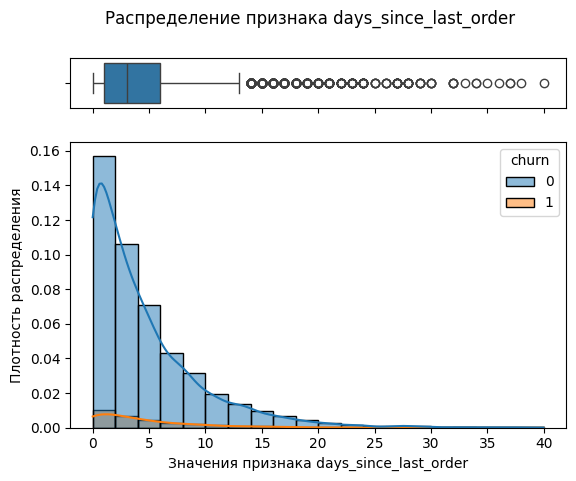

       days_since_last_promo
count            9338.000000
mean               14.562969
std                15.308919
min                 0.000000
25%                 4.000000
50%                10.000000
75%                20.000000
max               140.000000


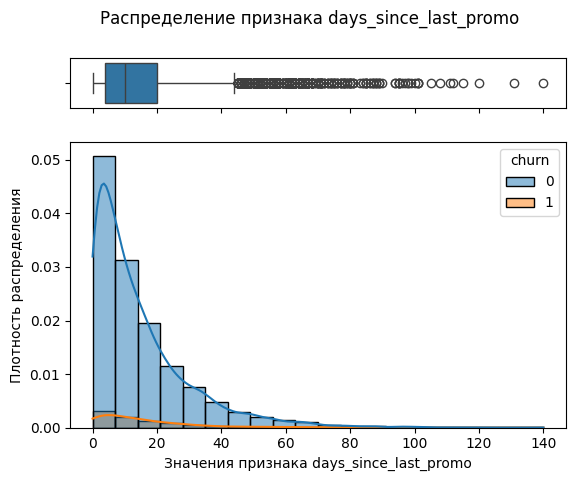

In [35]:
def box_hist(df, column, title=None, bins=20, hue='churn'):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
    print(df[[column]].describe())
    sns.boxplot(df[column], orient='h', ax=ax_box)
    sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=True, stat='density')

    f.suptitle(f'Распределение признака {column}' if title is None else title)
    ax_box.set(xlabel='')
    ax_hist.set(
        xlabel=f'Значения признака {column}',
        ylabel='Плотность распределения'
    )
    plt.show()

box_hist(df, 'days_since_last_order')
box_hist(df, 'days_since_last_promo')

Распределения значений в столбцах 'days_since_last_order' и 'days_since_last_promo' выглядят естесственными. Выбросы не требуют дополнительно обработки.

       order_frequency_month
count            9454.000000
mean                4.025081
std                 2.830559
min                 0.011046
25%                 1.931762
50%                 3.378246
75%                 5.434299
max                27.389318


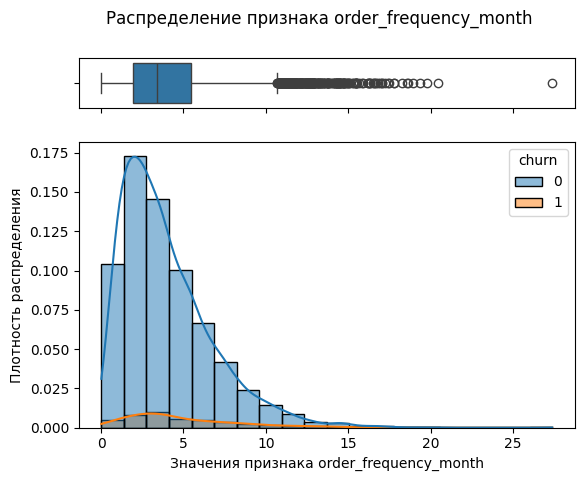

       order_frequency_week
count           9659.000000
mean               0.929998
std                0.657909
min               -0.169131
25%                0.445322
50%                0.783019
75%                1.258550
max                6.302624


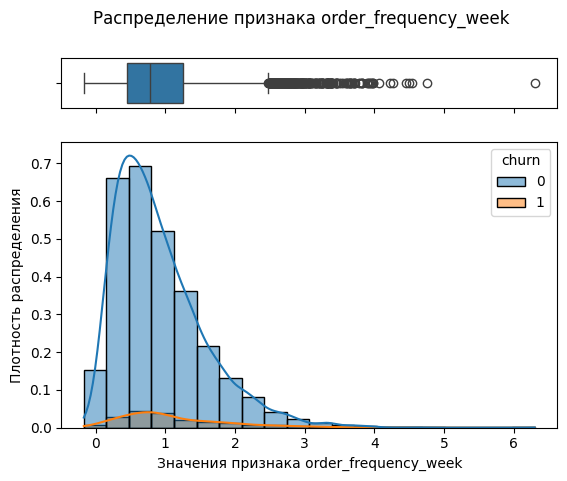

In [36]:

box_hist(df, 'order_frequency_month')
box_hist(df, 'order_frequency_week')

Значения order_frequency_month не требует обработки, зато order_frequency_week имеет отрицательные значения, которые необходимо заменить. Оценим количество таких записей:

In [37]:
print(
    f'Количество строк с отрицательными значениями признака',
    f'order_frequency_month: {len(df[df['order_frequency_week'] < 0])}',
)

Количество строк с отрицательными значениями признака order_frequency_month: 74


Требуется применить клиппинг, преобразующий отрицательные значения к нулю, к данной колонке во время обработки.

       avg_order_value
count      9476.000000
mean       1063.254822
std         707.615045
min         -32.075932
25%         552.806327
50%         898.368853
75%        1405.845229
max        5901.965278


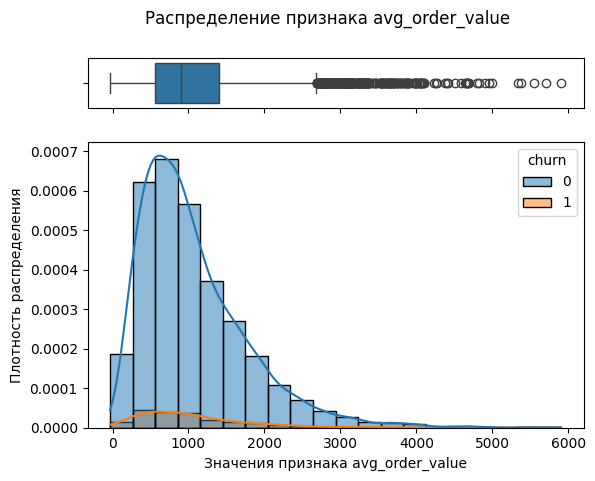

       median_order_value
count         9232.000000
mean           452.643042
std            258.899193
min            -10.353340
25%            263.584473
50%            405.841711
75%            591.515371
max           2189.101644


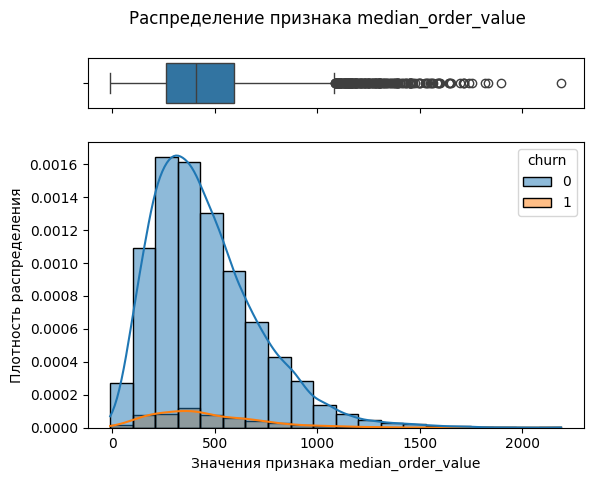

In [38]:

box_hist(df, 'avg_order_value')
box_hist(df, 'median_order_value')

К колонкам median_order_value и avg_order_value тоже требуют преобразования с клиппингом отрицательных значений в ноль.

       total_spent_last_month
count             9748.000000
mean              1945.439275
std               2375.596627
min                -43.716463
25%                628.239460
50%               1294.345827
75%               2475.248185
max              79298.849570


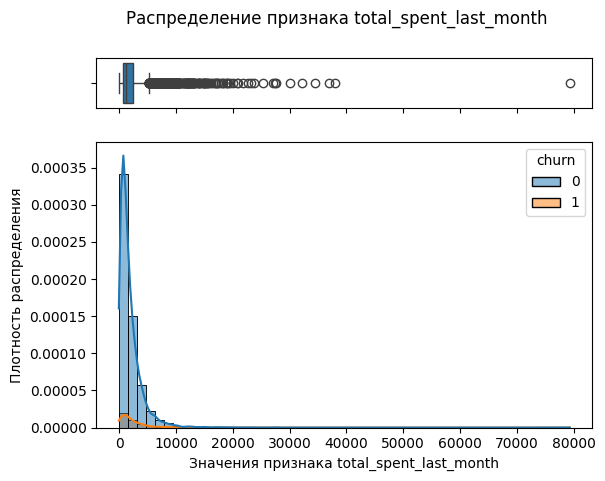

       total_spent_last_week
count            9120.000000
mean              412.764040
std               446.166446
min             -2290.559468
25%               136.251186
50%               287.099474
75%               549.310546
max              8615.988952


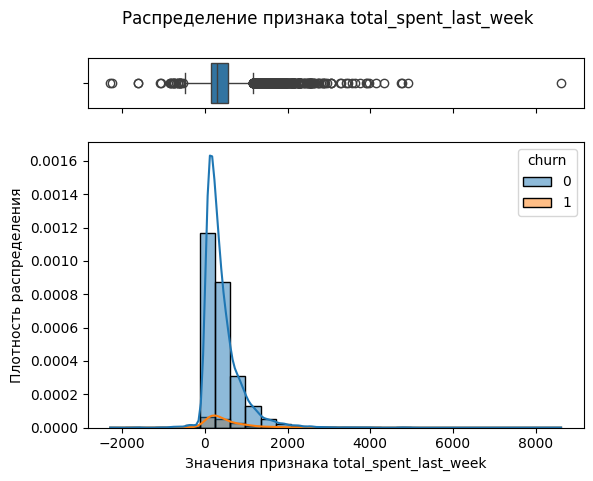

In [39]:
box_hist(df, 'total_spent_last_month', bins=50)
box_hist(df, 'total_spent_last_week', bins=30)

Значения в столбцах total_spent_last_month и total_spent_last_week также имеют выбросы и аномальные отрицательные значения. Необходимо применить клиппинг для отбрасывания отрицательных значений. Длинных правый хвост можно будет убрать с помощью логарифмического преобразования.

       review_rating_last_10
count            9362.000000
mean                4.207272
std                 0.782584
min                 1.415526
25%                 3.675187
50%                 4.205958
75%                 4.718466
max                 7.384425


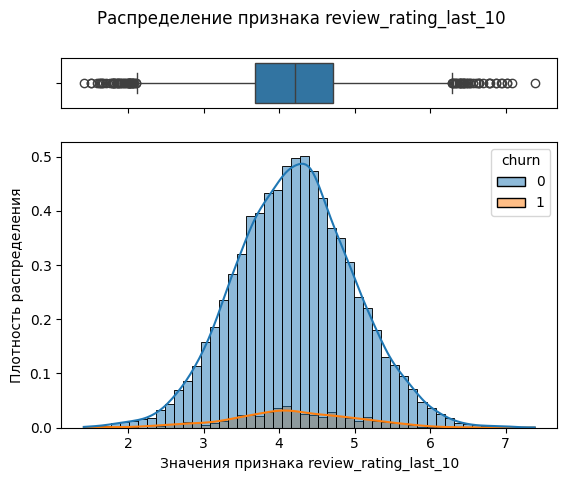

       review_rating_last_1
count           9214.000000
mean               4.022551
std                1.205782
min               -0.897000
25%                3.217563
50%                3.989637
75%                4.844709
max                8.558443


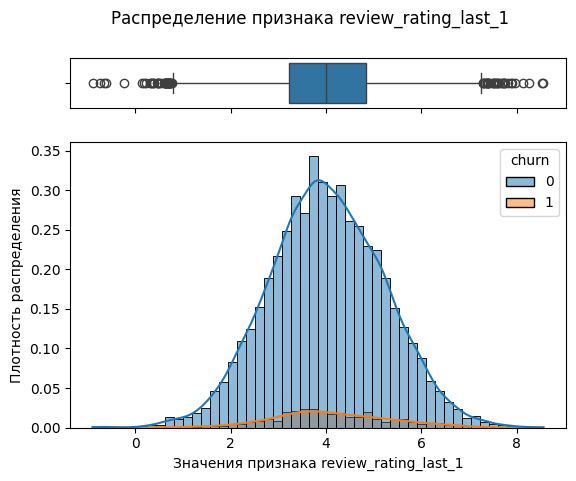

In [40]:
box_hist(df, 'review_rating_last_10', bins=50)
box_hist(df, 'review_rating_last_1', bins=50)


Значения review_rating_last_10 и review_rating_last_1 нормально распределены. В столбце review_rating_last_1 встречаются аномальные отрицательные значения, которые можно преобразовать в 0 с помощью клиппинга.

       discount_usage_rate
count          9653.000000
mean              0.283965
std               0.158722
min               0.002162
25%               0.159470
50%               0.263945
75%               0.386869
max               0.887301


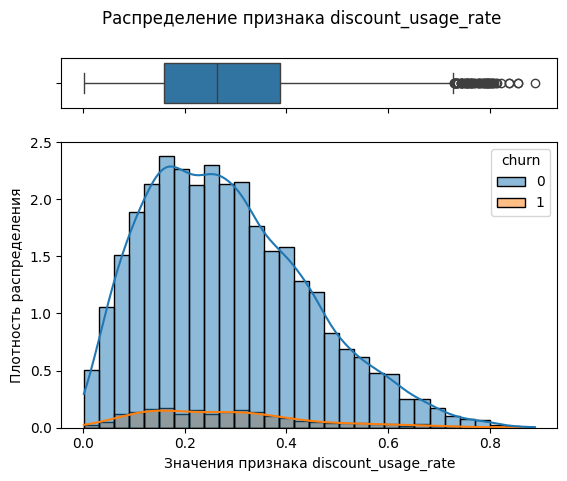

In [41]:
box_hist(df, 'discount_usage_rate', bins=30)


Столбец discount_usage_rate не содержит выбросов, требующих обработки.

In [42]:
print('Частота значений app_craches_last_month в нормализованном виде:')
round(df['app_crashes_last_month'].value_counts(dropna=False, normalize=True) * 100, 2)



Частота значений app_craches_last_month в нормализованном виде:


app_crashes_last_month
0.0    34.09
1.0    33.60
2.0    17.42
NaN     6.92
3.0     6.21
4.0     1.47
5.0     0.23
6.0     0.06
7.0     0.01
Name: proportion, dtype: float64

В столбце app_crashes_last_month нет аномальных значений. Только у 34% пользователей приложение работает без сбоев.

       app_opens_per_week
count         9179.000000
mean            11.327660
std             14.512342
min              0.000000
25%              6.335269
50%              9.214974
75%             12.715057
max            224.587876


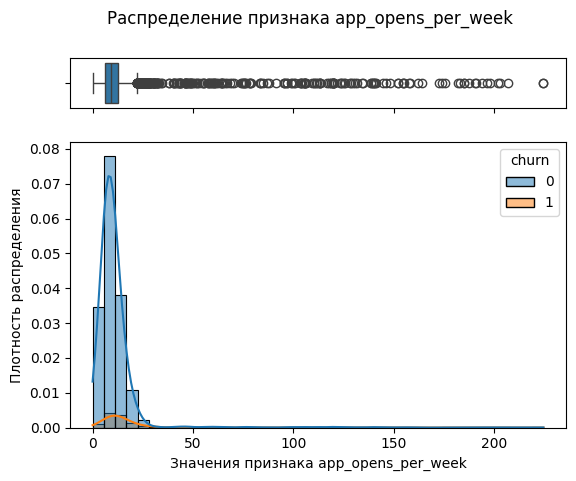

In [43]:
box_hist(df, 'app_opens_per_week', bins=40)


У столбца app_opens_per_week длинный правых хвост. Вероятно есть кагорта пользователей очень часто открывающая приложение (возможно у них СДВГ, либо мы имеем дело с роботными сессиями, которые мониторят конкурентов). Сложно себе представить пользоватлелей, которые открывают приложение более 50 раз в неделю. Возможно еще, что это тестировщики, но их как-то многовато.

Значения данного столбца необходимо преобразовать с помощью взятия квадратного корня. Такое сильное сжатие, какое дает логарифм, здесь не требуется по причине небольшого превышения среднего значения в хвосте распределения всего на 1 порядок.

### Корреляционный анализ

Проведем корреляционный анализ между признаками и целевой переменной, чтобы определить силу связи.


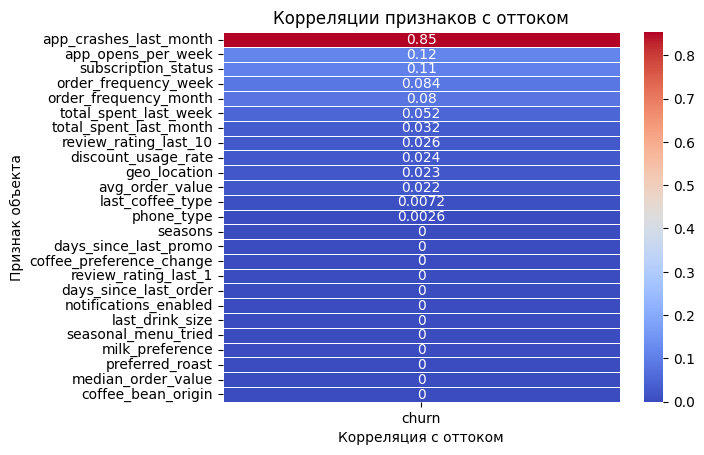

In [44]:
ALL_FEATURES = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'seasonal_menu_tried',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'app_opens_per_week',
    'notifications_enabled',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'seasons',
    'days_since_last_promo',
    'phone_type',
    'coffee_preference_change',
    'geo_location',
    'churn',
]

interval_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'app_opens_per_week',
    'app_crashes_last_month',
    'days_since_last_promo',
    'review_rating_last_10',
    'review_rating_last_1',
]

TARGET = 'churn'

corr_matrix = df[ALL_FEATURES].phik_matrix(interval_cols=interval_cols)

data_heatmap = corr_matrix.loc[corr_matrix.index != TARGET][[TARGET]].sort_values(by=TARGET, ascending=False)

sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляции признаков с оттоком')
plt.xlabel('Корреляция с оттоком')
plt.ylabel('Признак объекта')
plt.show()

Корреляционная матрица выявляет активную связь признака app_crashes_last_month (количество сбоев приложения заказа доставки кофе) с целевой переменной churn.

В совокупности с обнаруженным фактом того, что 2/3 пользователей сталкиваются с крашами приложения, данная корреляция выглядит как минимум правдоподобно.

In [45]:
df.groupby('app_crashes_last_month', dropna=False).agg({
    'user_id': 'count',
    'churn': 'mean',
})

,user_id,churn
app_crashes_last_month,,
0.0,3421,0.005554
1.0,3372,0.009193
2.0,1748,0.050343
3.0,623,0.409310
4.0,148,0.959459
5.0,23,1.000000
6.0,6,1.000000
7.0,1,1.000000
NaN,694,0.053314


Как видно из группировки, чем больше количество крашей приложения у пользователей за последний месяц, тем с большей интенсивностью они покидают сервис доставки кофе.

Кстати будет заметить, что 700 записей в выборке не содержат значения, но судя по доле пользователей покинувших севис (5%) в данной группе, пропуски необходимо заменить не на моду и не на медиану, а на 2, так как с двумя крашами приложения целевая переменная в среднем становится равной единице у 5% пользователей.

На основе анализа связи других признаков с целевой переменной, можно не включать в обучение такие признаки как

- seasons
- days_since_last_promo
- coffee_preference_change
- review_rating_last_1
- days_since_last_order
- notifications_enabled
- last_drink_size
- seasonal_menu_tried
- milk_preference
- median_order_value
- coffee_bean_origin

Однако предоставим модели право выбора признаков на первом этапе. После анализа коэффициентов линейной формулы, в случае необходимости, удалим лишние признаки.


### Вывод по первичному анализу данных


Датасет содержит 10450 объектов с 26 признаками, из которых целевая переменная churn имеет сильный дисбаланс классов (6% положительного класса).

- Обнаружены 814 неявных дубликатов, которые были удалены.

- Пропуски присутствуют в 25 колонках (1-10%), для их заполнения разработаны специфичные стратегии: days_since_last_order восстанавливается из days_since_last_promo, total_spent_last_week вычисляется как total_spent_last_month/4, app_opens_per_week моделируется линейной зависимостью от order_frequency_week. Данные стратегии сложны в имплементации и будут использованы в случае неудовлетворительного качества модели. Вместо них на первом этапе будем заменять пропуски медианными значениями либо модой в случае категориальных признаков. 
- Выявлены аномальные отрицательные значения в нескольких числовых признаках, требующие клиппинга.
- Корреляционный анализ показал сильную связь app_crashes_last_month с целевой переменной (2/3 пользователей сталкиваются с крашами приложения).
- Категориальные признаки будут кодироваться через OneHotEncoder (9 признаков) и TargetEncoder (geo_location с 100 значениями).
- Признаки с низкой корреляцией (seasons, days_since_last_promo и др.) оставлены для первичного обучения с последующим анализом коэффициентов модели.


В завершении анализа удалим колонку user_id как несущественную:

In [46]:
df.drop(columns=['user_id'], inplace=True)

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [47]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y,
)
print(
    f'X_train_val размер {X_train_val.shape}',
    f'y_train_val размер {y_train_val.shape}',
    f'X_test размер {X_test.shape}',
    f'y_test размер {y_test.shape}',
    sep = '\n',
)

X_train_val размер (8028, 25)
y_train_val размер (8028,)
X_test размер (2008, 25)
y_test размер (2008,)


In [48]:

OHE_FEATURES = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'seasons',
    'phone_type',
]

TARGET_ENCODED_FEATURES = [
    'geo_location',
]

NUM_FEATURES = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'seasonal_menu_tried',
    'app_opens_per_week',
    'notifications_enabled',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'coffee_preference_change',
]


# Кастомный клиппер. Негативы и пропуски в медианы
class NegativeClipper(BaseEstimator, TransformerMixin):
    def __init__(self, handle_zero=False):
        self.medians = {}
        self.handle_zero = handle_zero

    def fit(self, X, y=None):
        for col in X.columns:
            self.medians[col] = X[col].median()
        return self

    def transform(self, X):
        X = X.copy()
        for col, median in self.medians.items():
            X[col] = X[col].astype(float)
            if self.handle_zero:
                X.loc[X[col] <= 0, col] = median
            else:
                X.loc[X[col] < 0, col] = median
            X[col] = X[col].fillna(median)
        return X

    def get_feature_names_out(self, input_features=None):
        """Возвращает названия признаков без изменений"""
        if input_features is None:
            return self.feature_names_in_
        return input_features


cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
])

cat_target_encoded_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(
        target_type='binary',
        smooth='auto',
        shuffle=True,
        random_state=RANDOM_STATE,
    )),
])

num_pipeline = Pipeline([
    ('negative_clipper', NegativeClipper()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    [
        ('num', num_pipeline, NUM_FEATURES),
        ('cat_ohe', cat_ohe_pipeline, OHE_FEATURES),
        ('cat_taret_encoded', cat_target_encoded_pipeline, TARGET_ENCODED_FEATURES),
    ]
)


Определим главные пайплайны для моодели логистической регрессии и DummmyClassifier. Последний будем использовать как бейзлайн.


In [49]:
main_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE)),
])

dummy_classifier_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dummy', DummyClassifier(strategy='stratified')),
])

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

Обучим с помощью двух пайплайнов и кросс валидации модели логистической регрессии и бейзлайн. 

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
METRICS = ['average_precision', 'f1']  # PR-AUC

pipeline_cv_results = cross_validate(
    main_pipeline,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=METRICS,
    n_jobs=-1,
    return_estimator=True,
    return_train_score=True,
)

dummy_results = cross_validate(
    dummy_classifier_pipeline,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=METRICS,
    n_jobs=-1,
    return_estimator=True,
)



Теперь получим метрики обученных моделей. Для логрега сравним метрики валидации с метриками на тренировочной выборке, чтобы оценить переобучение.

In [51]:
result_metrics = []

def append_metrics(result_metrics, model_name, cv_results, test_or_train='test'):
    result_metrics.append({
        'model': model_name,
        'pr-auc': cv_results[f'{test_or_train}_average_precision'].mean(),
        'f1': cv_results[f'{test_or_train}_f1'].mean(),
    })

append_metrics(result_metrics, 'dummy', dummy_results)
append_metrics(result_metrics, 'main(val)', pipeline_cv_results, test_or_train='test')
append_metrics(result_metrics, 'main(train)', pipeline_cv_results, test_or_train='train')


pd.DataFrame(result_metrics)

,model,pr-auc,f1
0,dummy,0.060462,0.063141
1,main(val),0.662182,0.565324
2,main(train),0.690525,0.581059


Какие выводы можно сделать по полученными метрикам:

1. Метрика PR-AUC в 10 раз лучше, чем у dummy классификатора, что говорит уже о довольно хороших результатах при первом подходе.
2. pr_auc на трейне 0.03 больше, чем на валидации, что сигнализирует о незначительном переобучении


Обучим финальную модель на всех train+val данных и проверим ее на тестовой выборке.

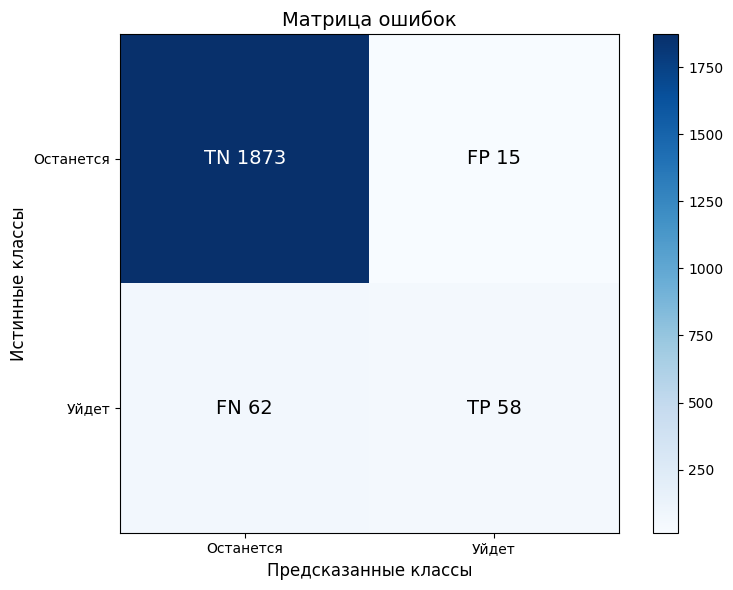

Расшифровка матрицы ошибок:
True Negatives (TN):  1873 - правильно предсказали Останется
False Positives (FP): 15 - ошибочно предсказали Уйдет
False Negatives (FN): 62 - ошибочно предсказали Останется
True Positives (TP):  58 - правильно предсказали Уйдет


In [52]:
final_model = main_pipeline.fit(X_train_val, y_train_val)
dummy_classifier_pipeline.fit(X_train_val, y_train_val)


def confusion_matrix_displayed(y_true, y_pred, true_desc='Уйдет', false_desc='Останется'):
    cm = confusion_matrix(y_true, y_pred)

    # Визуализируем матрицу
    plt.figure(figsize=(8, 6))

    # Отображаем матрицу как изображение
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im)

    # Добавляем подписи осей
    plt.xlabel('Предсказанные классы', fontsize=12)
    plt.ylabel('Истинные классы', fontsize=12)
    plt.title('Матрица ошибок', fontsize=14)

    # Настраиваем метки на осях
    tick_marks = [0, 1]
    plt.xticks(tick_marks, [false_desc, true_desc])
    plt.yticks(tick_marks, [false_desc, true_desc])

    # Матрица имеет структуру:
    matrix_desc = [
        ['TN', 'FP'],
        ['FN', 'TP'],
    ]

    # Добавляем числовые значения в ячейки
    for i in range(2):
        for j in range(2):
            plt.text(j, i, f'{matrix_desc[i][j]} {cm[i, j]}',
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=14)

    plt.tight_layout()
    plt.show()


    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tp = cm[1, 1]

    print('Расшифровка матрицы ошибок:')
    print(f'True Negatives (TN):  {tn} - правильно предсказали {false_desc}')
    print(f'False Positives (FP): {fp} - ошибочно предсказали {true_desc}')
    print(f'False Negatives (FN): {fn} - ошибочно предсказали {false_desc}')
    print(f'True Positives (TP):  {tp} - правильно предсказали {true_desc}')

y_pred_test = main_pipeline.predict(X_test)
y_pred_proba_test = main_pipeline.predict_proba(X_test)

y_pred_dummy_test = dummy_classifier_pipeline.predict(X_test)
y_pred_proba_dummy_test = dummy_classifier_pipeline.predict_proba(X_test)

confusion_matrix_displayed(y_test, y_pred_test)


Матрица ошибок показывает, что модель относительно неплохо справляется с отрицательным классом, но есть точки роста в полноте для положительного класса.
Чтобы убедиться в этом построим отчет классификации:

In [53]:
cr = classification_report(y_test, y_pred_test)
pr_auc_main = average_precision_score(y_test, y_pred_proba_test[:, 1])
print(f'Модель LogisticRegression (PR-AUC {pr_auc_main:.4f}):', cr, sep='\n')
cr_dummy = classification_report(y_test, y_pred_dummy_test)
pr_auc_dummy = average_precision_score(y_test, y_pred_proba_dummy_test[:, 1])
print(f'Модель Dummy (PR-AUC {pr_auc_dummy:.4f}):', cr_dummy, sep='\n')

Модель LogisticRegression (PR-AUC 0.7042):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1888
           1       0.79      0.48      0.60       120

    accuracy                           0.96      2008
   macro avg       0.88      0.74      0.79      2008
weighted avg       0.96      0.96      0.96      2008

Модель Dummy (PR-AUC 0.0597):
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1888
           1       0.06      0.07      0.07       120

    accuracy                           0.89      2008
   macro avg       0.50      0.50      0.50      2008
weighted avg       0.89      0.89      0.89      2008



Эта же проблема видна на метрике recall в отчете классификации: только половину ушедших пользователей мы смогли обнаружить.

Построим график PR-curve для наших моделей

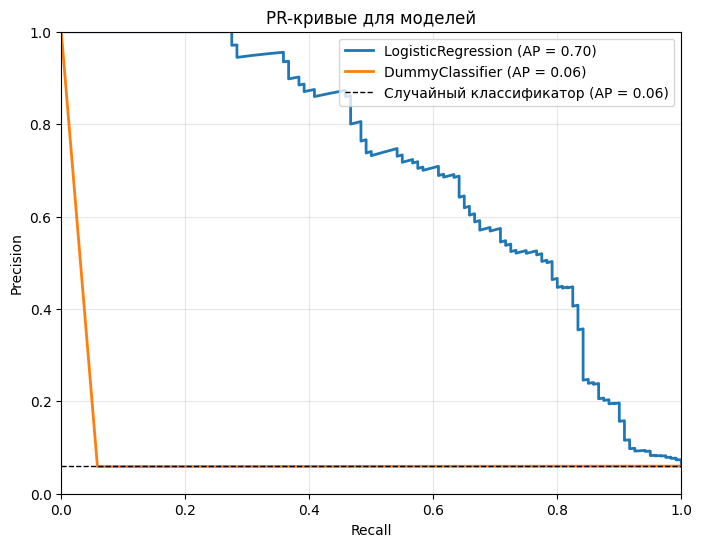

In [54]:
def show_pr_curve(y_test, y_pred_list, model_names_list):
    # Рассчитываем PR-кривые и PR-AUC для каждой модели
    assert len(y_pred_list) == len(model_names_list)

    pr_values = []

    for i in range(len(y_pred_list)):
        y_pred = y_pred_list[i][:,1]
        model_name = model_names_list[i]
        precision_a, recall_a, _ = precision_recall_curve(y_test, y_pred)
        pr_auc_a = average_precision_score(y_test, y_pred)
        pr_values.append({
            'model_name': model_name,
            'precision': precision_a,
            'recall': recall_a,
            'pr_auc': pr_auc_a,
        })

    # Построим график
    plt.figure(figsize=(8, 6))

    for pr_val in pr_values:
        plt.plot(
            pr_val['recall'],
            pr_val['precision'],
            label=f'{pr_val['model_name']} (AP = {pr_val['pr_auc']:.2f})', linewidth=2)

    baseline = sum(y_test) / len(y_test)
    plt.axhline(y=baseline, color='k', linestyle='--',
                label=f'Случайный классификатор (AP = {baseline:.2f})', linewidth=1)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('PR-кривые для моделей')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

show_pr_curve(
    y_test,
    [y_pred_proba_test, y_pred_proba_dummy_test],
    ['LogisticRegression', 'DummyClassifier'],
)

График precision-recall кривой также иллюстрирует, что обученная модель лучше случайного классификатора. В последствие будем использовать примененные функции для выбора лучшей модели.

Оценим, какие признаки оказывают влияние на предсказание по весам линейной формулы:

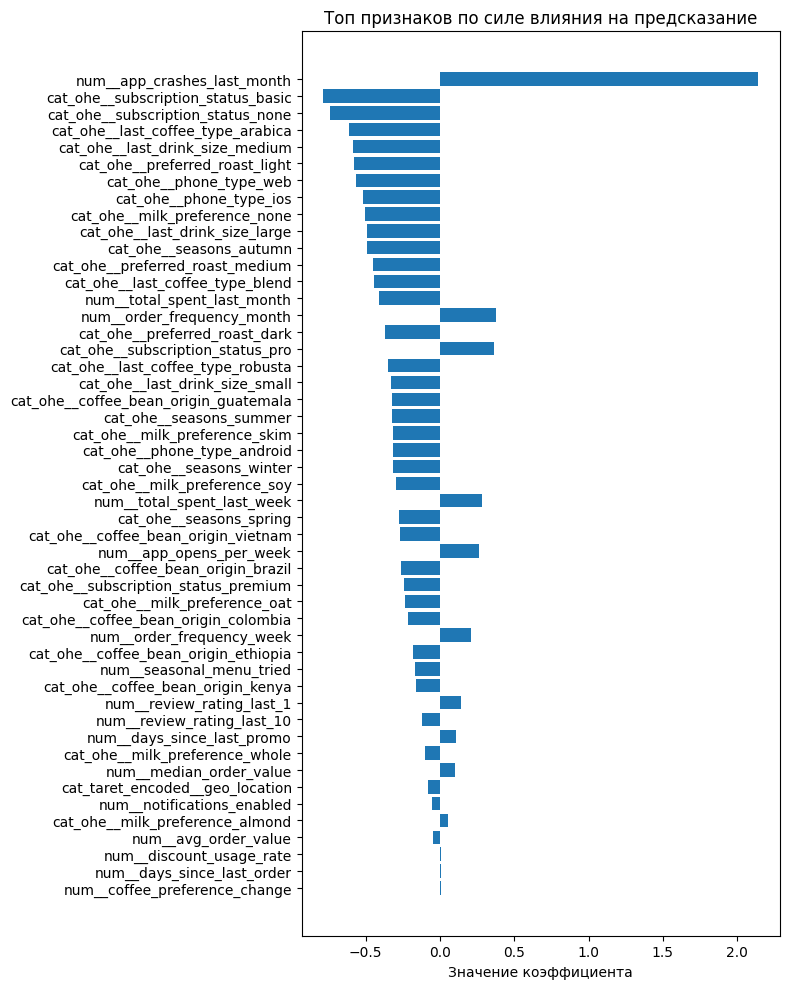

,feature,coefficient,abs_coefficient
0,num__app_crashes_last_month,2.141501,2.141501
1,cat_ohe__subscription_status_basic,-0.785139,0.785139
2,cat_ohe__subscription_status_none,-0.737764,0.737764
3,cat_ohe__last_coffee_type_arabica,-0.609810,0.609810
4,cat_ohe__last_drink_size_medium,-0.582823,0.582823
5,cat_ohe__preferred_roast_light,-0.582085,0.582085
6,cat_ohe__phone_type_web,-0.566997,0.566997
7,cat_ohe__phone_type_ios,-0.520142,0.520142
8,cat_ohe__milk_preference_none,-0.507891,0.507891
9,cat_ohe__last_drink_size_large,-0.490183,0.490183


In [55]:
def feature_importance(main_pipeline):
    # Получаем коэффициенты
    coefficients = main_pipeline.named_steps['model'].coef_[0]
    intercept = main_pipeline.named_steps['model'].intercept_[0]

    # Получаем названия признаков
    feature_names = main_pipeline.named_steps['preprocessor'].get_feature_names_out()

    # DataFrame для анализа для удобства анализа коэффициентов
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)

    # Визуализируем важность признаков:
    plt.figure(figsize=(8, 10))
    top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
    plt.barh(range(len(top_features)), top_features['coefficient'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Значение коэффициента')
    plt.title('Топ признаков по силе влияния на предсказание')
    plt.tight_layout()
    plt.show()

    return {
        'weights': coef_df.reset_index(drop=True),
        'intercept': intercept
    }

feature_importance(main_pipeline)['weights']

Мы снова видим, что влияние признака с количеством крашей приложения находится в топе.

## Этап 5. Создание новых признаков


Попробуем внедрить следюующие признаки:

1. Квадрат app_crashes_last_month: это наиболее важный признак. Возведение в квадрат усилит влияние больших значений: пользователи с 2+ крашами будут сильнее отличаться от пользователей с 1 крашем.
2. Логарифм total_spent_last_month: в анализе выбросов сделан вывод, что есть длинный правый хвост в указанных данных - проверим, поможет ли логарифм, если он сожмет выбросы и сделает распределение более нормальным.
3. Комбинация subscription_status и app_crashes_last_month: предположительно пользователи с платной подпиской на доставку кофе сильнее должны реагировать на краши приложения. 

Для определения способа комбинации, определим, какую выручку приносят пользователи разных подписок:

In [56]:
df['has_crushes'] = (df['app_crashes_last_month'] > 0).astype(int)
subscriptions_stats = df.groupby('subscription_status', dropna=False).agg(
    user_count = ('subscription_status', 'size'),
    sum_month_spent = ('total_spent_last_month', 'sum'),
    mean_month_spent = ('total_spent_last_month', 'mean'),
    app_opens_per_week = ('app_opens_per_week', 'mean'),
    has_crashes_rate = ('has_crushes', 'mean'),
    churn_rate = ('churn', 'mean'),
)
subscriptions_stats['mean_value_per_user'] = (
    subscriptions_stats['sum_month_spent'] /
    subscriptions_stats['user_count']
).astype(int)

subscriptions_stats['lost_rubles_per_month'] = (
    subscriptions_stats['churn_rate'] *
    subscriptions_stats['mean_value_per_user'] *
    subscriptions_stats['user_count']
).astype(int)
subscriptions_stats


,user_count,sum_month_spent,mean_month_spent,app_opens_per_week,has_crashes_rate,churn_rate,mean_value_per_user,lost_rubles_per_month
subscription_status,,,,,,,,
basic,2754,5.120966e+06,1906.539922,10.837949,0.589325,0.053377,1859,273273
none,3679,7.113108e+06,1999.187293,9.248479,0.587388,0.050014,1933,355672
premium,1839,3.321661e+06,1852.571500,13.525432,0.599782,0.071234,1806,236585
pro,872,1.716284e+06,2035.924471,16.143076,0.595183,0.107798,1968,184992
NaN,892,1.692122e+06,1949.449773,12.163091,0.577354,0.051570,1896,87216


In [57]:
# посчитаем долю оттока в группе пользователей с крашами и без крашей приложения
df.groupby(['has_crushes'])['churn'].mean()

has_crushes
0    0.013609
1    0.092214
Name: churn, dtype: float64

По таблице можно сделать вывод:
- самая большая группа пользователей - без подписки (3.7к). Но это непостоянные пользователи, которые скорее всего не настроены на долгое сотрудничество
- пользователи pemium и pro составляют группу в 2.7к пользователей и примерно равны количеству пользователей с подпиской basic
- подписочные клиенты наиболее привязаны к сервису, так как наиболее часто открывают приложение (mean_app_opens_per_week у pro = 16, у пользователей без подписки - 9)
- больше всего страдают от крашей в приложении pro, premium, basic клиенты - у этих групп самый высокий churn rate - 10.8%, 7.1%, 5.3% сооветственно. 
- у группы пользователей, которые сталкиваются с крашами приложения доля оттока составляет 9%, тогда как у тех, кто не сталкивается с подобными проблемами - только 1%!
- странно, но премиум и про не приносят значительно больше выручки в рассчете на 1 пользователя, хотя ожидалось, что они покупают более дорогие позиции и больше тратят.

Если учесть долю ушедших пользователей (churn_rate) и выручку на пользователя (mean_value_per_user) и количество пользователей в группе подписки, то можно подсчитать потерянные бизнесом денежные средства от каждой группы в месяц:
- basic 273к рублей
- none 356к рублей
- premium 237к рублей
- pro 185к рублей
- NaN (группа с пропусками в столбце подписки) - 87к рублей

Бизнес теряет больше всего от ухода пользователей без подписки, но это волатильная группа с пользователями, которые пробуют сервис, поэтому это ожидаемые потери.

В группе пользователей с подписочной моделью потери бизнеса значительны, хотя данные пользователи уже показали свою лояльность, но при этом из-за большого оттока бизнес теряет в совокупности почти 700к рублей в месяц.


Визуализируем некоторые характеристики приведенной таблицы:

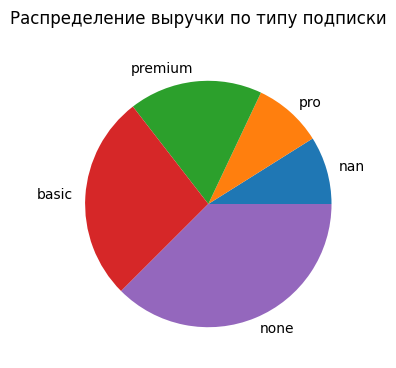

In [58]:
subscriptions_stats[['sum_month_spent']].sort_values(by='sum_month_spent', ascending=True).plot(
    kind='pie',
    subplots=True,
    title='Распределение выручки по типу подписки',
    figsize=(8, 4),
    legend=False,
)
plt.show()

Подписочная модель приносит более половины выручки, поэтому пользователи с подписками наиболее важны для бизнеса.

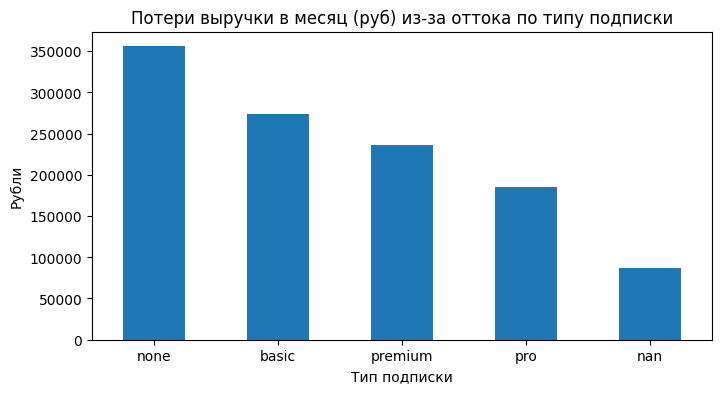

In [59]:
subscriptions_stats.reset_index().sort_values(by='lost_rubles_per_month', ascending=False).plot(
    kind='bar',
    x='subscription_status',
    y=['lost_rubles_per_month'],
    # subplots=True,
    title='Потери выручки в месяц (руб) из-за оттока по типу подписки',
    figsize=(8, 4),
    legend=False,
    xlabel='Тип подписки',
    ylabel='Рубли',
    rot=0,
)
plt.show()

Из-за оттока подписочных клиентов бизнес теряет сотни тысяч рублей в месяц.

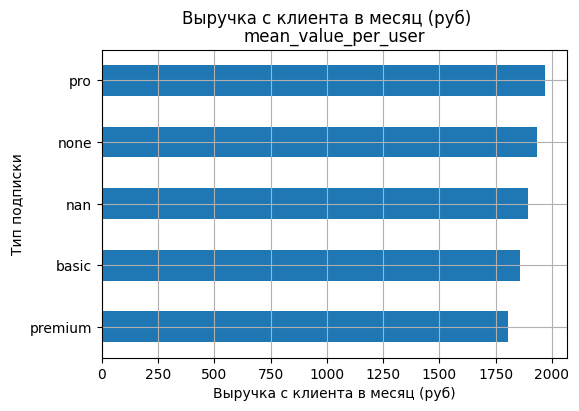

In [60]:
subscriptions_stats.reset_index(drop=False).sort_values(by='mean_value_per_user', ascending=True).plot(
    kind='barh',
    subplots=True,
    y='mean_value_per_user',
    x='subscription_status',
    title='Выручка с клиента в месяц (руб)',
    xlabel='Выручка с клиента в месяц (руб)',
    ylabel='Тип подписки',
    figsize=(6, 4),
    legend=False,
    grid=True,
)
plt.show()

Клиенты из pro тратят больше всего в среднем рублей в месяц (около 2000), что не сильно больше, чем пользователи без подписки. Просто отметим этот факт, хотя ожидали тут увидеть большую разницу.

Добавим в новый пайплайн шаг с добавлением новых признаков и обучем модель:

In [61]:
def create_features(X):
    X_enhanced = X.copy()

    # 1. Квадрат крашей
    X_enhanced['app_crashes_squared'] = X_enhanced['app_crashes_last_month'] ** 2

    # 2. Логарифмы месячных трат
    X_enhanced['log_total_spent_month'] = np.log1p(
        X_enhanced['total_spent_last_month'].fillna(0).clip(lower=0)
    )

    # 3. Падение приложения у подписочных пользователей
    X_enhanced['is_paid_subscription'] = (
        X_enhanced['subscription_status']
        .fillna('none')
        .isin([
            'premium',
            'pro',
            'basic',
        ])
    ).astype(float)
    X_enhanced['paid_user_crashes'] = (
        X_enhanced['is_paid_subscription'] * X_enhanced['app_crashes_last_month']
    )

    return X_enhanced

NUM_FEATURES_ENHANCED = NUM_FEATURES + [
    'app_crashes_squared',
    'log_total_spent_month',
    'paid_user_crashes',
    'is_paid_subscription',
]

preprocessor_enhanced = ColumnTransformer([
    ('num', num_pipeline, NUM_FEATURES_ENHANCED),
    ('cat_ohe', cat_ohe_pipeline, OHE_FEATURES),
    ('cat_taret_encoded', cat_target_encoded_pipeline, TARGET_ENCODED_FEATURES),
])


main_pipeline_enhanced = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessor', preprocessor_enhanced),  # используем новый preprocessor
    ('model', LogisticRegression(random_state=RANDOM_STATE)),
])

pipeline_enhanced_cv_results = cross_validate(
    main_pipeline_enhanced,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=METRICS,
    n_jobs=-1,
    return_estimator=True,
    return_train_score=True,
)

result_metrics_enhanced = result_metrics.copy()
append_metrics(result_metrics_enhanced, 'main_enhanced(val)',
               pipeline_enhanced_cv_results, test_or_train='test')
append_metrics(result_metrics_enhanced, 'main_enhanced(train)',
               pipeline_enhanced_cv_results, test_or_train='train')
pd.DataFrame(result_metrics_enhanced)
# feature_importance(final_model_extended)


,model,pr-auc,f1
0,dummy,0.060462,0.063141
1,main(val),0.662182,0.565324
2,main(train),0.690525,0.581059
3,main_enhanced(val),0.674567,0.564406
4,main_enhanced(train),0.700640,0.584568


Нельзя утверждать, что новые признаки значительно улучшают модель, но получим финальные результаты на тестовой выборке для убедительности и посмотрим, где модель ошибается.

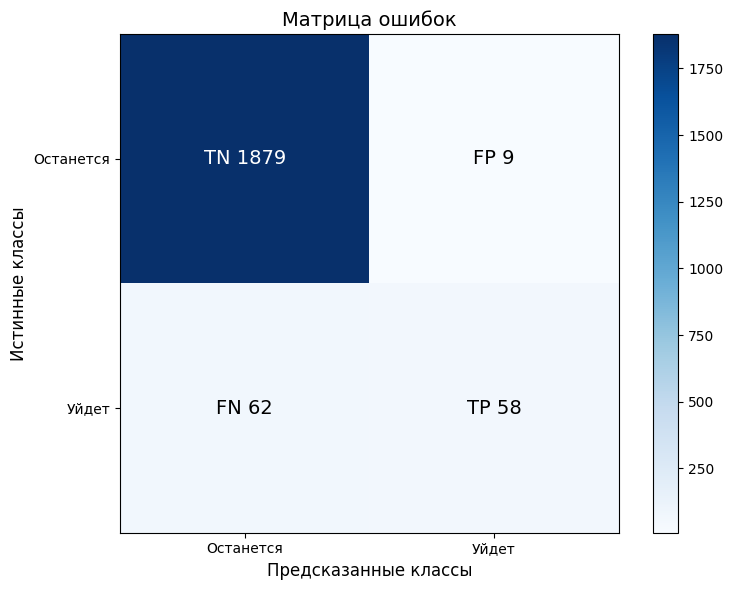

Расшифровка матрицы ошибок:
True Negatives (TN):  1879 - правильно предсказали Останется
False Positives (FP): 9 - ошибочно предсказали Уйдет
False Negatives (FN): 62 - ошибочно предсказали Останется
True Positives (TP):  58 - правильно предсказали Уйдет


In [62]:
final_model_enhanced = main_pipeline_enhanced.fit(X_train_val, y_train_val)
y_pred_test_enhanced = main_pipeline_enhanced.predict(X_test)
y_pred_proba_test_enhanced = main_pipeline_enhanced.predict_proba(X_test)
confusion_matrix_displayed(y_test, y_pred_test_enhanced)

In [63]:
cr_enhanced = classification_report(y_test, y_pred_test_enhanced)
pr_auc_main_enhanced = average_precision_score(y_test, y_pred_proba_test_enhanced[:, 1])
diff = pr_auc_main_enhanced - pr_auc_main
diff_pct = diff / pr_auc_main
print(f'Модель LogisticRegression enhanced'
      f'(PR-AUC {pr_auc_main_enhanced:.4f})(+{diff:.4f}/{diff_pct:.2%}):', cr_enhanced, sep='\n')

print(f'Модель LogisticRegression old'
      f'(PR-AUC {pr_auc_main:.4f}):', cr, sep='\n')

Модель LogisticRegression enhanced(PR-AUC 0.7090)(+0.0048/0.68%):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1888
           1       0.87      0.48      0.62       120

    accuracy                           0.96      2008
   macro avg       0.92      0.74      0.80      2008
weighted avg       0.96      0.96      0.96      2008

Модель LogisticRegression old(PR-AUC 0.7042):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1888
           1       0.79      0.48      0.60       120

    accuracy                           0.96      2008
   macro avg       0.88      0.74      0.79      2008
weighted avg       0.96      0.96      0.96      2008



Модель стала точнее в предсказании отрицательного класса (раньше было 15 FP, теперь 9, то есть precision 0.79->0.87!). Полнота предсказании положительного класса осталась практически без изменений.

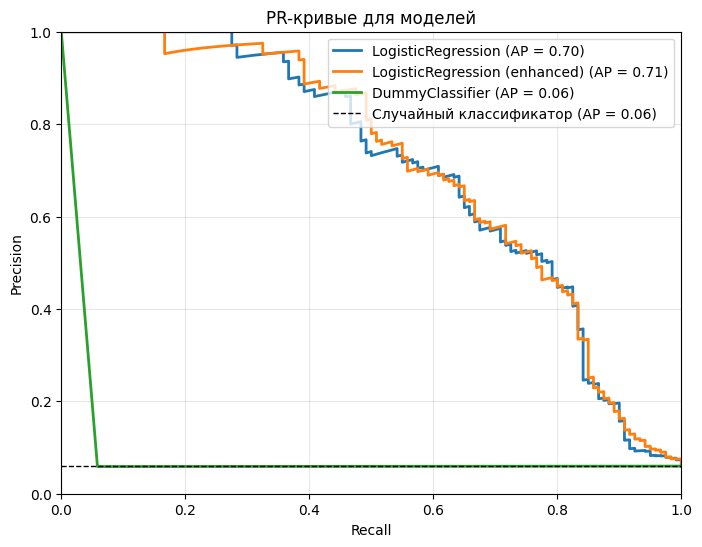

In [64]:
show_pr_curve(
    y_test,
    [y_pred_proba_test, y_pred_proba_test_enhanced, y_pred_proba_dummy_test],
    ['LogisticRegression', 'LogisticRegression (enhanced)', 'DummyClassifier'],
)

На графике RP-curve видно, что новая модель с расширенными признаками имеет чуть большую прощадь под кривой. Но разница едва заметра.

Проверим, как влияют новые признаки на предсказания модели по их весам.

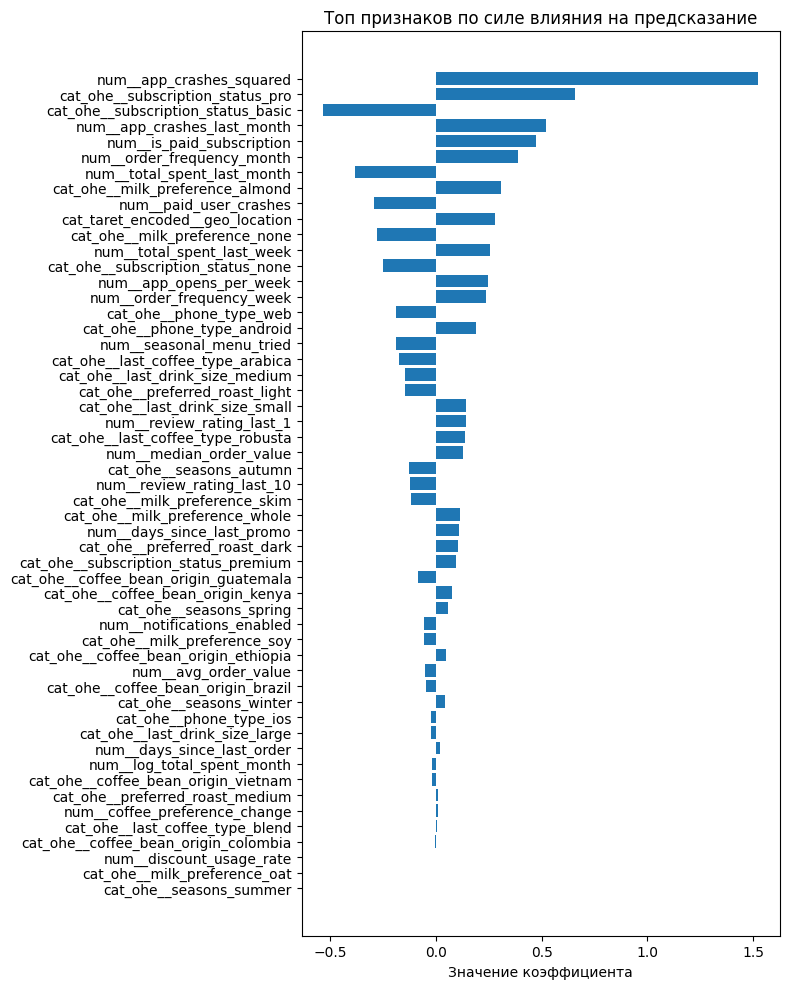

,feature,coefficient,abs_coefficient
0,num__app_crashes_squared,1.523936,1.523936
1,cat_ohe__subscription_status_pro,0.656328,0.656328
2,cat_ohe__subscription_status_basic,-0.531435,0.531435
3,num__app_crashes_last_month,0.519188,0.519188
4,num__is_paid_subscription,0.475152,0.475152
5,num__order_frequency_month,0.389925,0.389925
6,num__total_spent_last_month,-0.383510,0.383510
7,cat_ohe__milk_preference_almond,0.308752,0.308752
8,num__paid_user_crashes,-0.290899,0.290899
9,cat_taret_encoded__geo_location,0.281456,0.281456


In [65]:
feature_importance(main_pipeline_enhanced)['weights']

Видно, что добавленный признак квадрата app_crashes теперь в топе по значимости, значит признак полезен. Другие добавленные признаки оказались не столь полезными, но тоже добавляют свой вклад:
- is_paid_subscription на 5 месте 
- paid_user_crashes на 9 месте

Кроме того модель выявила признаки, которые практически не влияют на предсказания. Среди них несколько категориальных, закодированнных с помощью OHЕ, и числовой discount_usage_rate. Однако все коэффициенты ненулевые, то есть удалять их нецелесообразно, если мы не хотим потерять в качестве модели.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

Будем экспериментировать с параметры логистической регрессии:
- class_weight - задает веса классов при дисбалансе
- С - инвертированный параметр регуляризации - чем ближе к нулю, тем сильнее регуляризация
- penalty - тип регуляризации 
- max_iter - количество итераций обучения
- solver - алгоритм оптимизации


In [66]:
param_grid = [
    {
        'model__solver': ['liblinear', 'saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': np.linspace(0.01, 0.2, 10),
        'model__class_weight': [None, 'balanced'],
        'model__max_iter': [1000, 2000],
        'model__random_state': [RANDOM_STATE],
    },
]


scoring = {
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
}

grid_search = GridSearchCV(
    estimator=main_pipeline_enhanced,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='pr_auc',
    n_jobs=-1,
    verbose=3,
    return_train_score=True,
)

print("Начинаем перебор гиперпараметров...")
grid_search.fit(X_train_val, y_train_val)


Начинаем перебор гиперпараметров...
Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 4/5] END model__C=0.01, model__class_weight=None, model__max_iter=1000, model__penalty=l1, model__random_state=153, model__solver=liblinear; f1: (train=0.442, test=0.429) pr_auc: (train=0.669, test=0.624) precision: (train=0.982, test=0.900) recall: (train=0.285, test=0.281) total time=   0.1s
[CV 4/5] END model__C=0.01, model__class_weight=None, model__max_iter=1000, model__penalty=l2, model__random_state=153, model__solver=liblinear; f1: (train=0.524, test=0.496) pr_auc: (train=0.697, test=0.641) precision: (train=0.894, test=0.829) recall: (train=0.370, test=0.354) total time=   0.1s
[CV 1/5] END model__C=0.01, model__class_weight=None, model__max_iter=2000, model__penalty=l1, model__random_state=153, model__solver=liblinear; f1: (train=0.420, test=0.512) pr_auc: (train=0.641, test=0.724) precision: (train=0.954, test=1.000) recall: (train=0.269, test=0.344) total time=   0.2s
[CV 

,estimator,Pipeline(step..._state=153))])
,param_grid,"[{'model__C': array([0.01 ..., 0.2 ]), 'model__class_weight': [None, 'balanced'], 'model__max_iter': [1000, 2000], 'model__penalty': ['l1', 'l2'], ...}]"
,scoring,"{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall'}"
,n_jobs,-1
,refit,'pr_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,func,<function cre...t 0x1323af600>


In [67]:
# Результаты
print("\nЛучшие параметры:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nМетрики лучшей модели (CV):")
best_idx = grid_search.best_index_
results = grid_search.cv_results_
print(f"  PR-AUC: {results['mean_test_pr_auc'][best_idx]:.4f} ± {results['std_test_pr_auc'][best_idx]:.4f}")
print(f"  F1:     {results['mean_test_f1'][best_idx]:.4f} ± {results['std_test_f1'][best_idx]:.4f}")
print(f"  Recall: {results['mean_test_recall'][best_idx]:.4f} ± {results['std_test_recall'][best_idx]:.4f}")
print(f"  Precision: {results['mean_test_precision'][best_idx]:.4f} ± {results['std_test_precision'][best_idx]:.4f}")


results_df = pd.DataFrame(grid_search.cv_results_)
results_df_sorted = results_df.sort_values(by='mean_test_pr_auc', ascending=False)

pd.set_option('display.max_colwidth', 500) # для отображения параметров модели
print("\nТоп-3 комбинаций по PR-AUC:")
display(results_df_sorted[[
    'params',
    'mean_test_pr_auc',
    'mean_test_f1',
    'mean_test_recall',
    'mean_test_precision',
    'std_test_pr_auc',
]].head(3))




Лучшие параметры:
  model__C: 0.1577777777777778
  model__class_weight: None
  model__max_iter: 1000
  model__penalty: l1
  model__random_state: 153
  model__solver: liblinear

Метрики лучшей модели (CV):
  PR-AUC: 0.6823 ± 0.0404
  F1:     0.5540 ± 0.0552
  Recall: 0.4315 ± 0.0610
  Precision: 0.7870 ± 0.0608

Топ-3 комбинаций по PR-AUC:


,params,mean_test_pr_auc,mean_test_f1,mean_test_recall,mean_test_precision,std_test_pr_auc
116,"{'model__C': 0.1577777777777778, 'model__class_weight': None, 'model__max_iter': 2000, 'model__penalty': 'l1', 'model__random_state': 153, 'model__solver': 'liblinear'}",0.682335,0.554036,0.431508,0.786987,0.040437
112,"{'model__C': 0.1577777777777778, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__random_state': 153, 'model__solver': 'liblinear'}",0.682335,0.554036,0.431508,0.786987,0.040437
100,"{'model__C': 0.1366666666666667, 'model__class_weight': None, 'model__max_iter': 2000, 'model__penalty': 'l1', 'model__random_state': 153, 'model__solver': 'liblinear'}",0.682057,0.552810,0.431486,0.784162,0.040346


In [68]:
# Оценка на тесте
best_model = grid_search.best_estimator_
y_pred_test_grid = best_model.predict(X_test)
y_pred_proba_test_grid = best_model.predict_proba(X_test)

pr_auc_grid = average_precision_score(y_test, y_pred_proba_test_grid[:, 1])
diff_grid = pr_auc_grid - pr_auc_main_enhanced
diff_grid_pct = diff_grid / pr_auc_main_enhanced

print(f"PR-AUC на тесте: {pr_auc_grid:.4f}")
print(f"Разница с PR-AUC с предыдущей моделью (PR-AUC {pr_auc_main_enhanced:.4f}): +{diff_grid:.4f}/{diff_grid_pct:.2%}")



PR-AUC на тесте: 0.7168
Разница с PR-AUC с предыдущей моделью (PR-AUC 0.7090): +0.0077/1.09%


При подборе параметров, удалось найти более оптимальную модель и выбить +1% к целевой метрике.

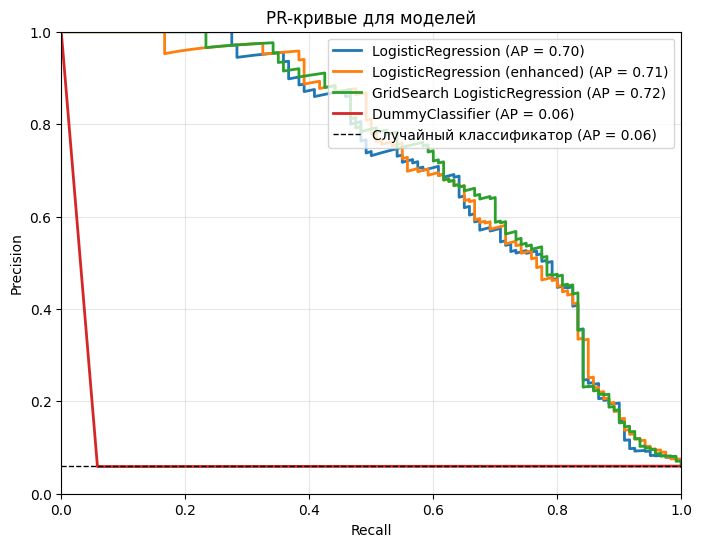

In [69]:
show_pr_curve(
    y_test,
    [
        y_pred_proba_test,
        y_pred_proba_test_enhanced,
        y_pred_proba_test_grid,
        y_pred_proba_dummy_test,
    ],
    [
        'LogisticRegression',
        'LogisticRegression (enhanced)',
        'GridSearch LogisticRegression',
        'DummyClassifier',
    ],
)

Все проиллистрированные RP-кривые обученных моделей логистической регрессии близки друг к другу.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


Теперь обучим финальную модель на объединенных данных тестовой и валидационной выборок.

In [74]:
final_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features, validate=False)),
    ('preprocessor', preprocessor_enhanced),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        C=0.1577777777777778,
        class_weight=None,
        max_iter=1000,
        penalty='l1',
        solver='liblinear',
    )),
])
final_pipeline.fit(X_train_val, y_train_val)
y_pred_final = final_pipeline.predict(X_test)
y_pred_final_proba = final_pipeline.predict_proba(X_test)

pr_auc_main_final = average_precision_score(y_test, y_pred_final_proba[:, 1])
diff_final = pr_auc_main_final - pr_auc_main
diff_final_pct = diff_final / pr_auc_main

print(f"PR-AUC финальной модели на тесте: {pr_auc_main_final:.4f}")
print(f"Разница с PR-AUC с первой моделью ({pr_auc_main:.4f}): +{diff_final:.4f}/{diff_final_pct:.2%}")

print('Отчет классификации:')
print(classification_report(y_test, y_pred_final))

PR-AUC финальной модели на тесте: 0.7168
Разница с PR-AUC с первой моделью (0.7042): +0.0125/1.78%
Отчет классификации:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1888
           1       0.84      0.47      0.60       120

    accuracy                           0.96      2008
   macro avg       0.90      0.73      0.79      2008
weighted avg       0.96      0.96      0.96      2008



## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

Финальная модель (LogisticRegression с оптимизированными по сетке гиперпараметрами) получила следующие метрики:
- PR-AUC: 0.7168 (целевая метрика)
- Precision для класса 1 (отток): 0.84
- Recall для класса 1 (churn): 0.47
- F1-score: 0.60

Сравнение с бейзлайном (DummyClassifier): 0.0597-> в 12 раз лучше.

Наиболее важные факторы влияющие на отток:

1. Количество крашей приложения за последний месяц. Интерпретация: пользователи, сталкиваясь с неработающим приложением, перестают пользоваться сервисом.
2. Статусы подписки pro (в сторону усиления оттока) или basic (в сторону ослабления оттока) также оказывают сильное влияние на отток. Вероятно пользователи с премиальными платными подписками (pro - 10.8% оттока, premium - 7.1%) сильнее реагируют на краши в приложении.

Следует отметить, что 2/3 пользователей сталкиваются с падением приложения за период, представленный в данных. Корреляция оттока с числом падений приложения самая значительная, причем чем больше раз пользователь сталкивается с неработающим приложением, тем больше вероятность оттока (при одном краше приложения в месяц у пользователя доля оттока составляет 1%, при двух крашах в месяц - 5%, при 3-х крашах - 40%!)

Влияние оттока на бизнес показатели компании:

- подписочные клиенты приносят более 50% выручки
- потери от оттока подписчиков составляют около 700 тыс.руб в месяц в том числе:
    - Подписка Basic - 273 тыс.руб в месяц
    - Подписка Pro - 185 тыс.руб в месяц
    - Подписка Premium - 237 тыс.руб в месяц

При улучшении модели этот факт был учтен и набор признаков был расширен:
- app_crashes_squared: количество крашей в месяц в квадрате (для усиления влияния фактора)
- is_paid_subscription: бинарный признак платной подписки (5-е место по важности)
- paid_user_crashes — взаимодействие подписки и крашей (9-е место)

Добавленные фичи улучшили целевую метрику на 0.7% (0.7042->0.7090)

Качество модели было выращено еще за счет подбора гиперпараметров: RP-AUC вырос на 1.1% (0.7090->0.7168).

На этапе анализа данных были выявлены пропуски и аномальные отрицательные значения. Для их обработки разработан компонент пайплайна NegativeClipper, который заменяет отрицательные значения на медианные. Пропуски были также заменены на медианные значения или моды для категориальных признаков.

Категориальные признаки с количеством уникальных значений до 6 были преобразованы с помощью OneHotEncoding. Признак geo_location был закодировать с помощью TragetEncoding.


Также были предложены несколько улучшений по предварительной обработке признаков, но было принято решение не применять их в виду удовлетворительного качества модели.

Рекомендации команде бизнеса:

Приоритет #1: Стабильность приложения
- Устранить краши — главная причина оттока
- Ожидается снижение доли оттока на 30-50%

Приоритет #2: Удержание подписчиков
- Фокус на Pro/Premium клиентов (10.8% и 7.1% оттока), работа с Basic подписчиками так выгодна, но потребует широкого охвата и дополнительных трат. 
- Потенциальная экономия: ~700 тыс. руб/мес за счет снижения оттока
- Способ реализации: персональные предложения для подписчиков, скидки и акции

Модель готова к продакшену и может использоваться для:
- Проактивного удержания клиентов (оценка риска по величине вероятности предсказания положительного класса: >0.7 - высокий риск потери клиента)
- Персонализации предложений на основе предсказания модели
- Приоритизации работы с клиентами высокого риска оттока

Также модель можно использовать для A/B тестирования стратегий удержания клиентов.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [71]:
VERSION=1.0
date = datetime.now().strftime('%Y_%m_%d')
model_name = f"coffee_shop_churn_model_v{VERSION}_{date}.joblib"

metadata = {
    'model_version': f'{VERSION}',
    'training_date': f'{date}',
    'pr_auc': pr_auc_main_final,
    'features': ALL_FEATURES,
}

joblib.dump(
    {
        'model': final_pipeline,
        'metadata': metadata
    },
    model_name,
)

['coffee_shop_churn_model_v1.0_2026_03_09.joblib']

In [78]:
df.head(1).to_json(orient='records', indent=4)

'[\n    {\n        "days_since_last_order":0.0,\n        "order_frequency_month":12.942519193,\n        "order_frequency_week":null,\n        "avg_order_value":316.833871889,\n        "median_order_value":260.6450902569,\n        "total_spent_last_month":3089.9910088367,\n        "total_spent_last_week":null,\n        "discount_usage_rate":0.3370306878,\n        "last_coffee_type":"blend",\n        "preferred_roast":"light",\n        "milk_preference":"almond",\n        "seasonal_menu_tried":null,\n        "coffee_bean_origin":"vietnam",\n        "last_drink_size":"large",\n        "subscription_status":"pro",\n        "app_opens_per_week":30.4683207114,\n        "notifications_enabled":1.0,\n        "review_rating_last_10":5.1767922695,\n        "review_rating_last_1":3.3022376735,\n        "app_crashes_last_month":null,\n        "seasons":"summer",\n        "days_since_last_promo":6.0,\n        "phone_type":"android",\n        "coffee_preference_change":0.0,\n        "geo_location":"

In [89]:
# Проверка работоспособности модели:
loaded_model = joblib.load(f'{model_name}')

user = pd.DataFrame([{
    "days_since_last_order":0.0,
    "order_frequency_month":12.942519193,
    "order_frequency_week":4,
    "avg_order_value":316.833871889,
    "median_order_value":260.6450902569,
    "total_spent_last_month":3089.9910088367,
    "total_spent_last_week":1000,
    "discount_usage_rate":0.3370306878,
    "last_coffee_type":"blend",
    "preferred_roast":"light",
    "milk_preference":"almond",
    "seasonal_menu_tried":1.0,
    "coffee_bean_origin":"vietnam",
    "last_drink_size":"large",
    "subscription_status":"pro",
    "app_opens_per_week":30.4683207114,
    "notifications_enabled":1.0,
    "review_rating_last_10":5.1767922695,
    "review_rating_last_1":3.3022376735,
    "app_crashes_last_month":4.0,
    "seasons":"summer",
    "days_since_last_promo":6.0,
    "phone_type":"android",
    "coffee_preference_change":0.0,
    "geo_location":"geo_75",
    # "churn":1,
}])

proba = loaded_model['model'].predict_proba(user)[:, 1]
print(f'Вероятность оттока пользователя: {proba[0]:.2%}')

assert proba[0] > 0.95, 'модель предсказывает неправильно!'

Вероятность оттока пользователя: 99.80%
